# Imports

In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.colors as mcolors
import os
import numpy as np
import cartopy.crs as ccrs
import pandas as pd
from datetime import datetime, timedelta
import seaborn as sns
from dask.diagnostics.progress import ProgressBar
from matplotlib.patches import Patch
from matplotlib.ticker import FormatStrFormatter
import xclim
from lmoments3.distr import gam, gev, gum


In [2]:
def get_refhistfut_quick(variable, folder = 'era5-cmip6_exp_ens'):
    hist = xr.open_zarr(f'/data/ecmwf_eib/data/{folder}/{variable}/{variable}_hist_allsources.zarr')[variable]
    fut = xr.open_zarr(f'/data/ecmwf_eib/data/{folder}/{variable}/{variable}_fut_allsources.zarr')[variable]
    return hist, fut

In [5]:
import sys
from pathlib import Path

# Resolve path from ./notebook up into ./indicator_delta_scaling/src
src_path = Path('../src').resolve()

if str(src_path) not in sys.path:
    sys.path.append(str(src_path))


%load_ext autoreload
%autoreload 2
from xids import IndicatorDeltaScaling, indicators, utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Testing IDS module

## TXx

In [6]:
tasmax_hist, tasmax_fut = get_refhistfut_quick('tasmax', folder = 'era5-cmip6_exp_ens',)

tasmax_ref = tasmax_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
tasmax_model = xr.concat([tasmax_hist.sel(source='simu'), tasmax_fut.sel(source='simu')], dim='time').chunk({'time': -1})
#tasmax_model

In [7]:

# Initialize class instance
ids = IndicatorDeltaScaling(
    hist_period=['1951', '1970'],
    fut_period=[['1971', '1990'], ['1991', '2010']]
)

# Compute TXX using xclim indicator function
txx_ref, txx_hist, txx_fut, txx_delta = ids.compute_indicator(
    indicator_func=xclim.indices.tx_max, 
    reference_data = tasmax_ref,
    model_data = tasmax_model,
    freq = 'YS',
    delta_mode='+',
    compute = True,
    short_name = 'txx',
    long_name = 'Maximum daily maximum temperature',
    units = 'ºC',
)


[########################################] | 100% Completed | 505.04 ms
[########################################] | 100% Completed | 409.49 ms
[########################################] | 100% Completed | 8.68 ss
[########################################] | 100% Completed | 1.42 sms
[########################################] | 100% Completed | 1.59 ss
[########################################] | 100% Completed | 1.44 sms


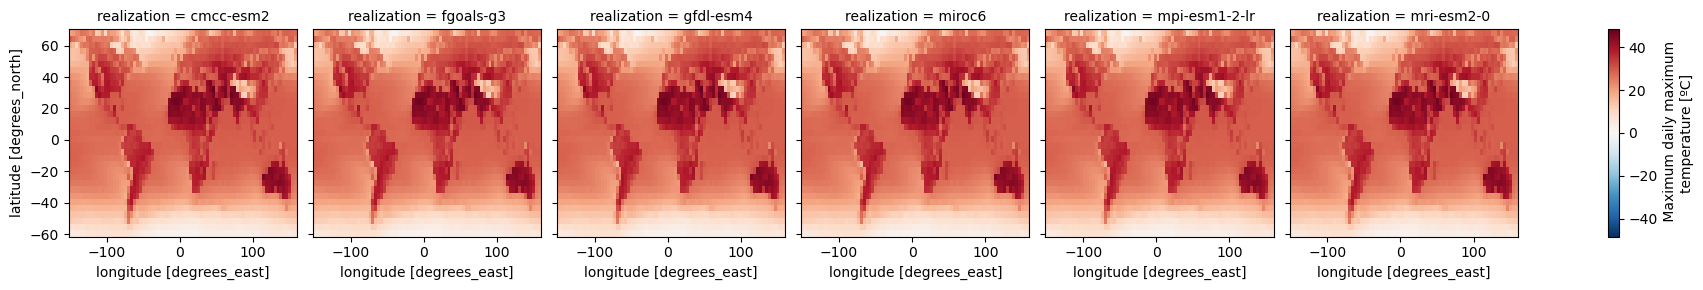

In [9]:
(txx_hist).plot(col='realization')

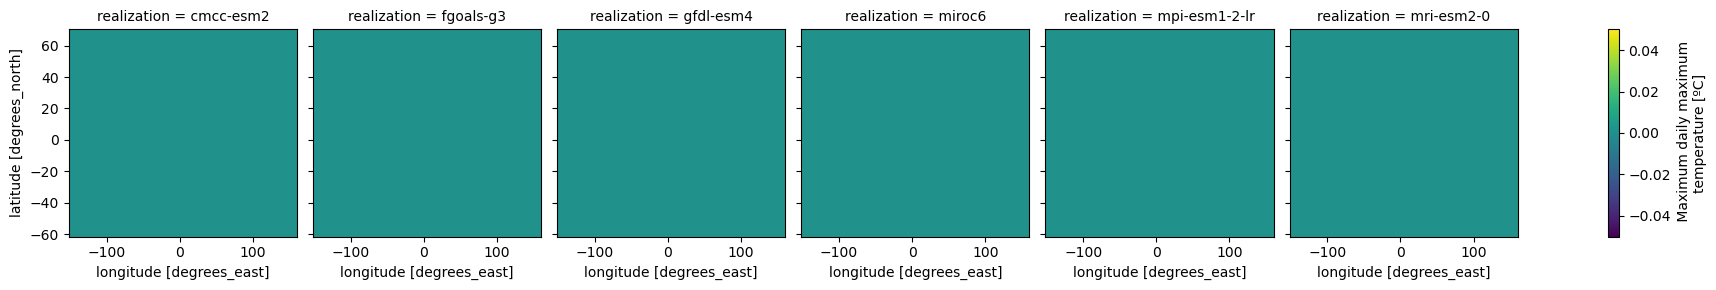

In [10]:
(txx_hist-txx_ref).plot(col='realization')

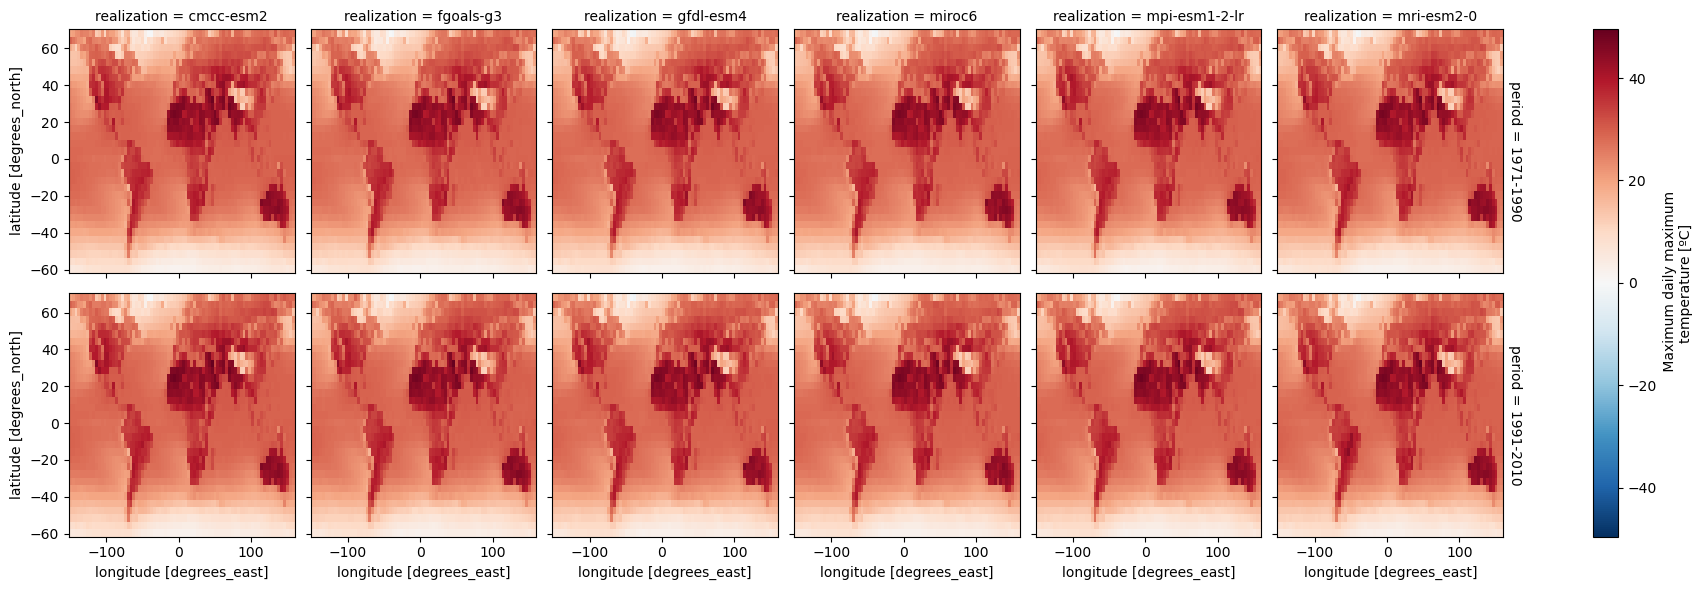

In [11]:
(txx_fut).plot(col='realization', row = 'period')

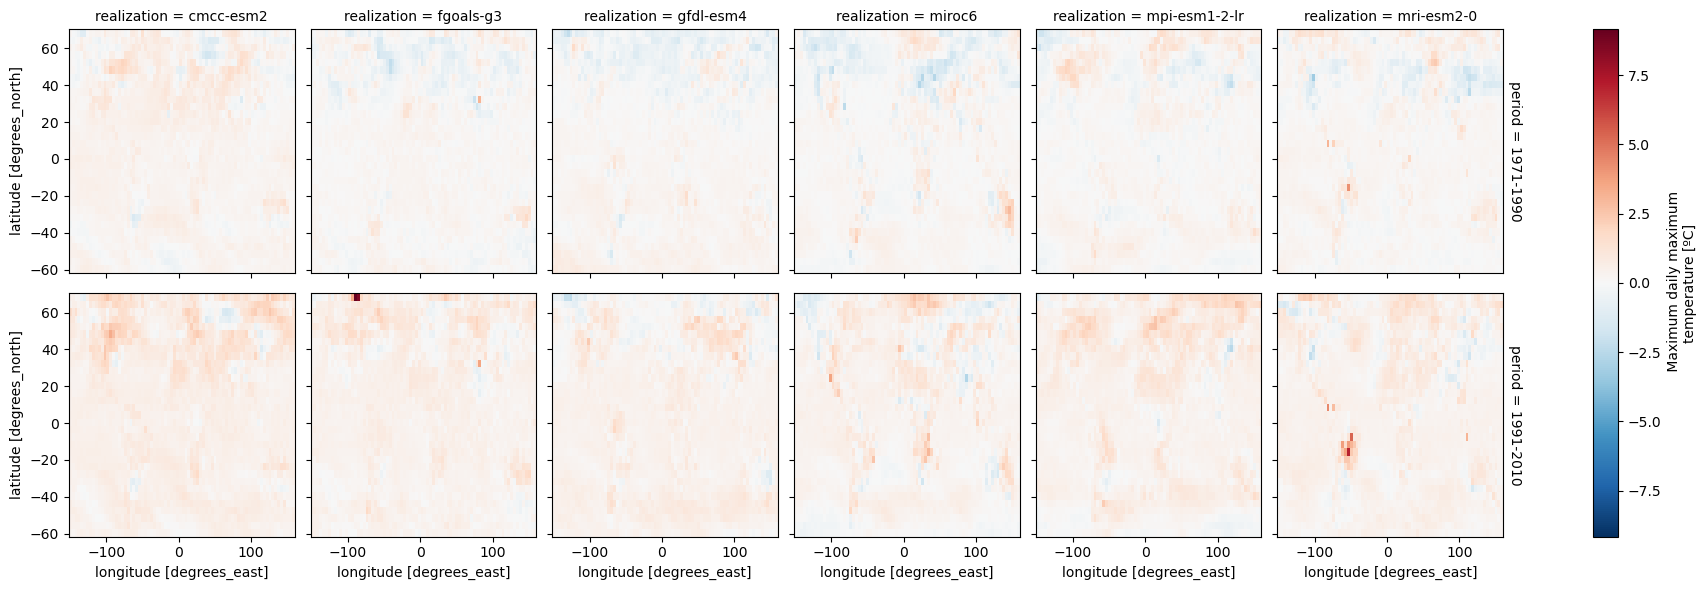

In [12]:
(txx_fut-txx_hist.isel(period=0)).plot(col='realization', row='period')

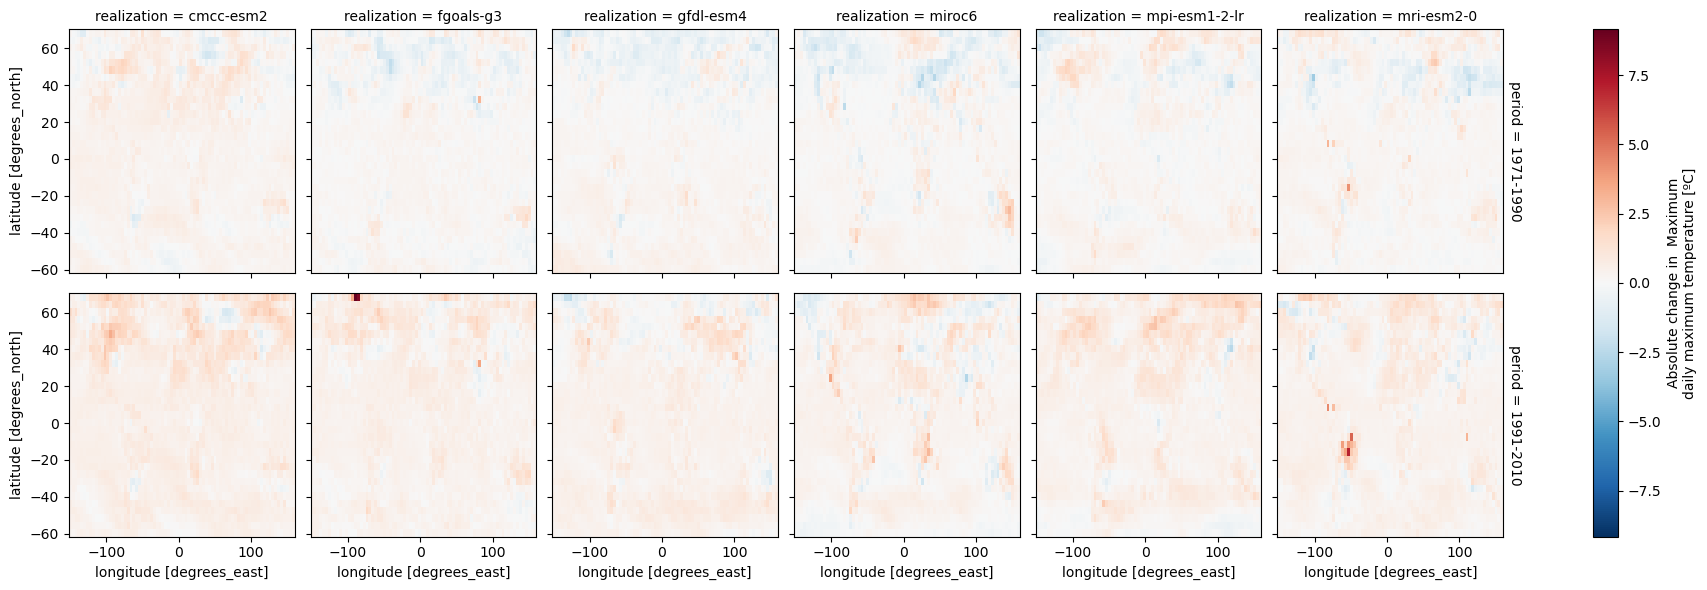

In [13]:
(txx_delta).plot(col='realization', row='period')

## RX1day

In [ ]:
pr_hist, pr_fut = get_refhistfut_quick('pr', folder = 'era5-cmip6_exp_ens',)

pr_ref = pr_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
pr_model = xr.concat([pr_hist.sel(source='simu'), pr_fut.sel(source='simu')], dim='time').chunk({'time': -1})
#pr_model

In [ ]:


# Initialize class instance
ids = IndicatorDeltaScaling(
    hist_period=['1951', '1970'],
    fut_period=[['1971', '1990'], ['1991', '2010']]
)

# Compute RX1day using xclim indicator function
rx1day_ref, rx1day_hist, rx1day_fut, rx1day_delta = ids.compute_indicator(
    indicator_func=xclim.indices.max_1day_precipitation_amount, 
    reference_data = pr_ref,
    model_data = pr_model,
    freq = 'YS',
    delta_mode='*',
    compute = True,
    short_name = 'rx1day',
    long_name = 'Maximum daily precipitation amount',
    units = 'mm',
    delta_factor_percentage = True,
)


[########################################] | 100% Completed | 202.21 ms
[########################################] | 100% Completed | 201.99 ms
[########################################] | 100% Completed | 916.73 ms
[########################################] | 100% Completed | 841.65 ms
[########################################] | 100% Completed | 823.47 ms
[########################################] | 100% Completed | 929.87 ms


/home/jpena/miniconda3/envs/xr2/lib/python3.13/site-packages/xclim/indices/fire/_cffwis.py:475: RuntimeWarning: invalid value encountered in divide
  (0.8 * dc * dmc) / (dmc + 0.4 * dc),  # *Eq.27a*#
/home/jpena/miniconda3/envs/xr2/lib/python3.13/site-packages/xclim/indices/fire/_cffwis.py:476: RuntimeWarning: invalid value encountered in divide
  dmc - (1.0 - 0.8 * dc / (dmc + 0.4 * dc)) * (0.92 + (0.0114 * dmc) ** 1.7),


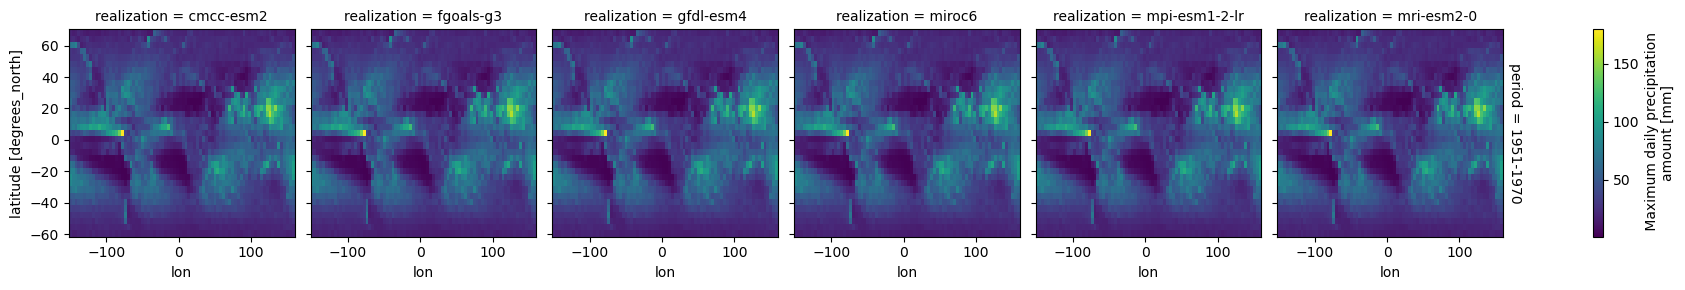

In [16]:
rx1day_hist.plot(col='realization', row = 'period')

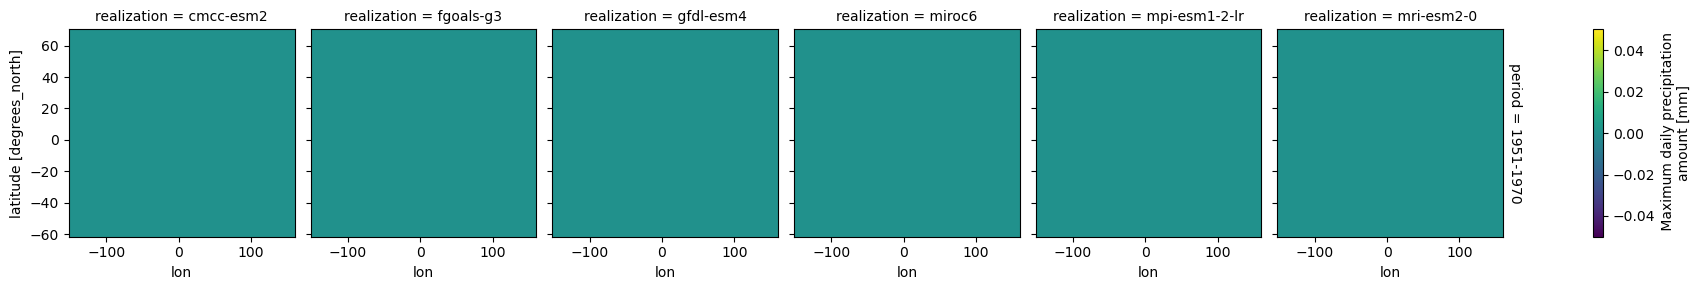

In [17]:
(rx1day_hist-rx1day_ref).plot(col='realization', row = 'period')

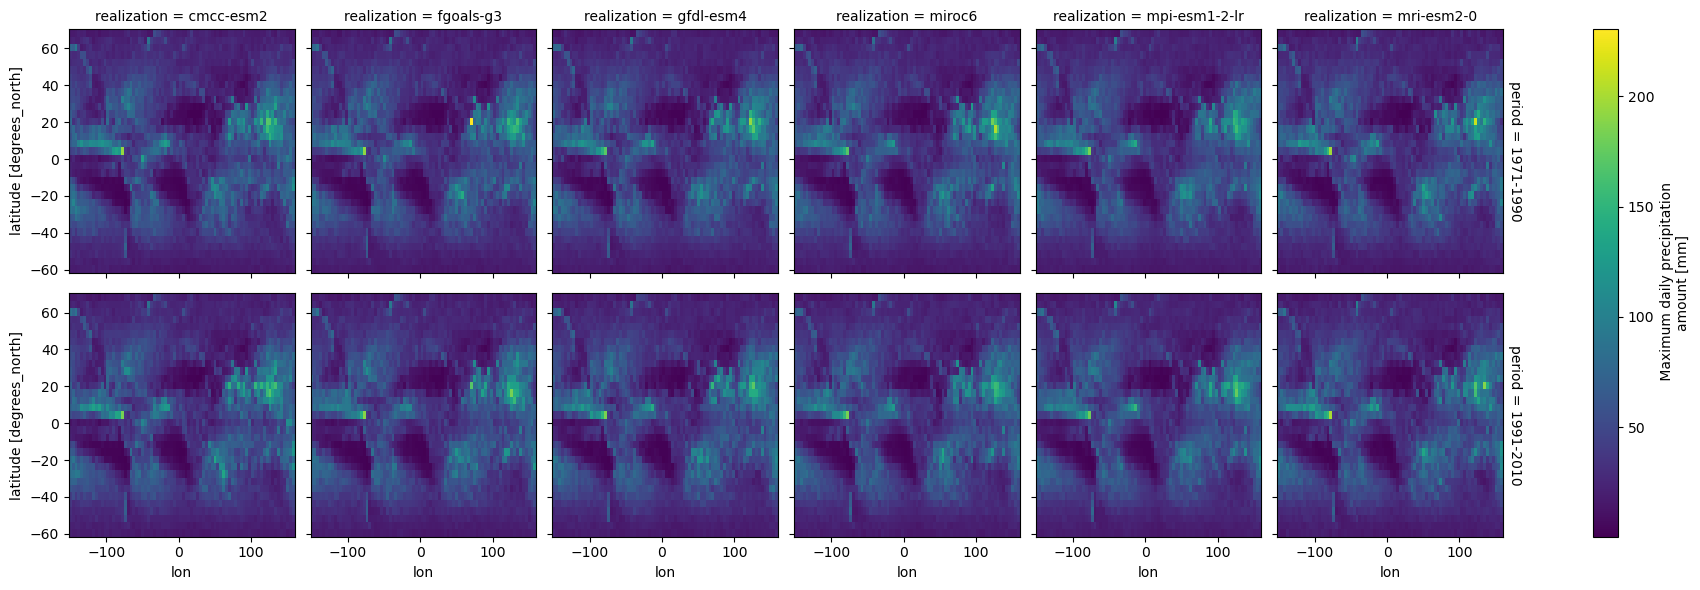

In [18]:
rx1day_fut.plot(col='realization', row = 'period')

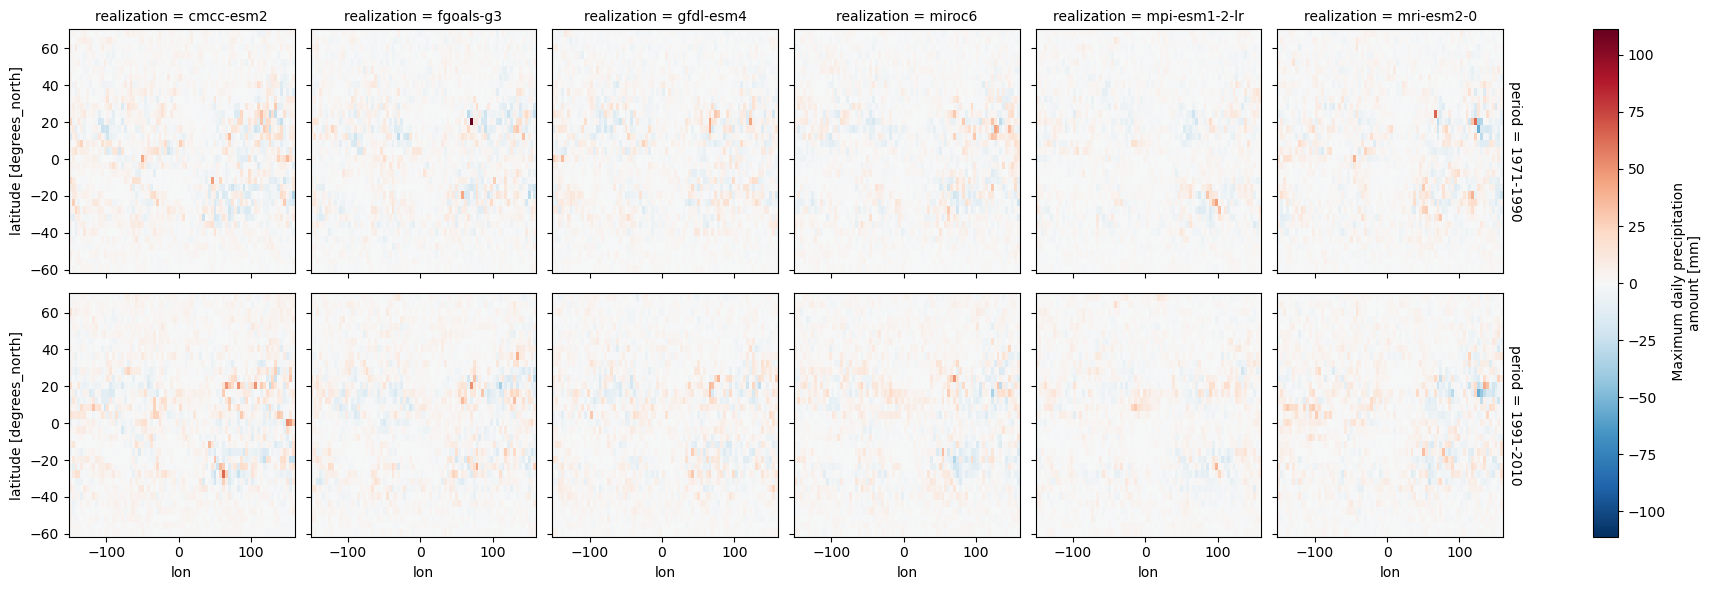

In [19]:
(rx1day_fut-rx1day_hist.isel(period=0)).plot(col='realization', row = 'period')

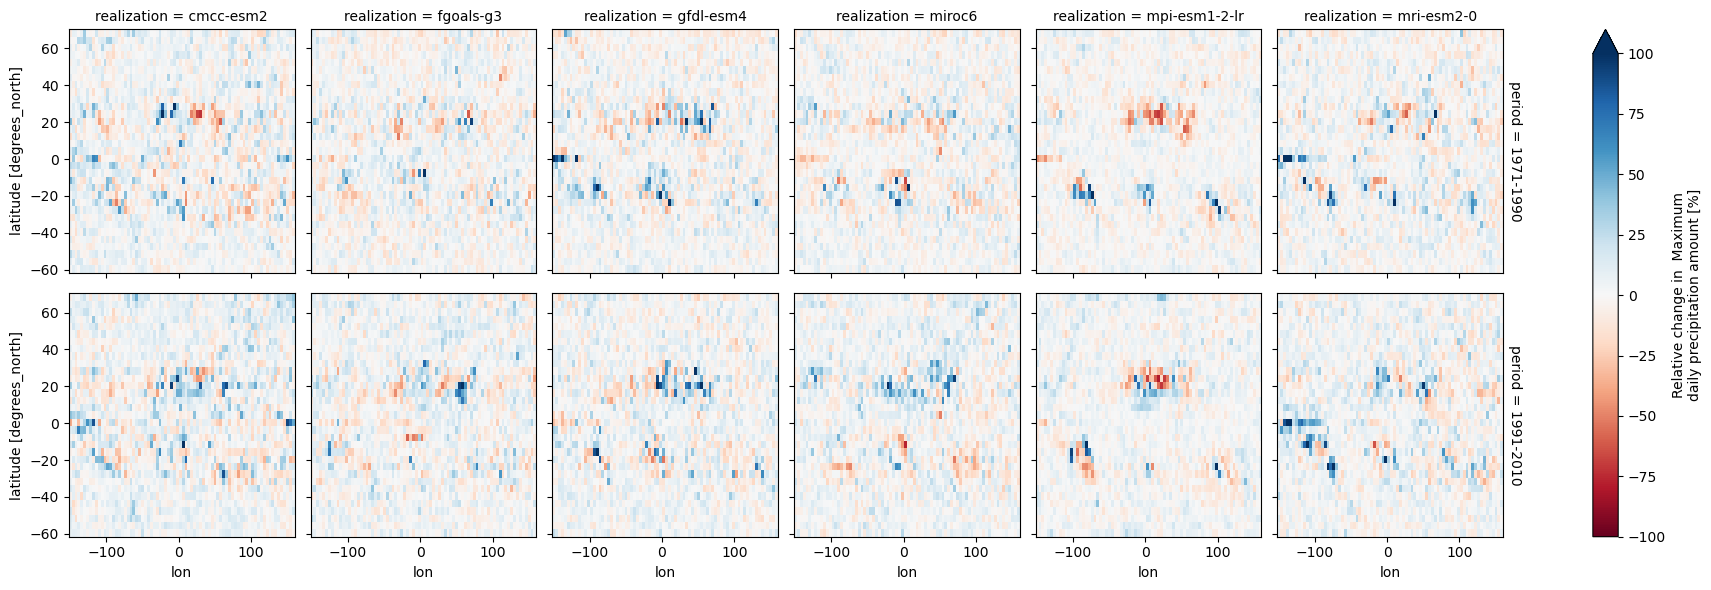

In [20]:
(rx1day_delta).plot(col='realization', row='period', vmin=-100, vmax=100, cmap='RdBu')

## RX1day_20yr

In [ ]:
pr_hist, pr_fut = get_refhistfut_quick('pr', folder = 'era5-cmip6_exp_ens',)

pr_ref = pr_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
pr_model = xr.concat([pr_hist.sel(source='simu'), pr_fut.sel(source='simu')], dim='time').chunk({'time': -1})
#pr_model

In [ ]:
# Initialize class instance
ids = IndicatorDeltaScaling(
    hist_period=['1951', '1970'],
    fut_period=[['1971', '1990'], ['1991', '2010']]
)

# Compute RX1day using xclim indicator function
rx1day_ref, rx1day_hist, rx1day_fut, rx1day_delta = ids.compute_indicator(
    indicator_func=xclim.indices.stats.frequency_analysis, 
    reference_data = pr_ref,
    model_data = pr_model,
    mode = 'max',
    t = 20,
    method = 'ML', #'PWM',
    dist = 'gumbel_r', #'gum',
    aggregation = None,
    freq = 'YS',
    delta_mode='*',
    compute = True,
    short_name = 'rx1day_20yr',
    long_name = 'Maximum daily precipitation amount in a 20-year period',
    units = 'mm',
)


[########################################] | 100% Completed | 1.52 ss
[########################################] | 100% Completed | 1.54 ss
[########################################] | 100% Completed | 8.38 sms
[########################################] | 100% Completed | 8.36 sms
[########################################] | 100% Completed | 8.29 sms
[########################################] | 100% Completed | 8.31 sms


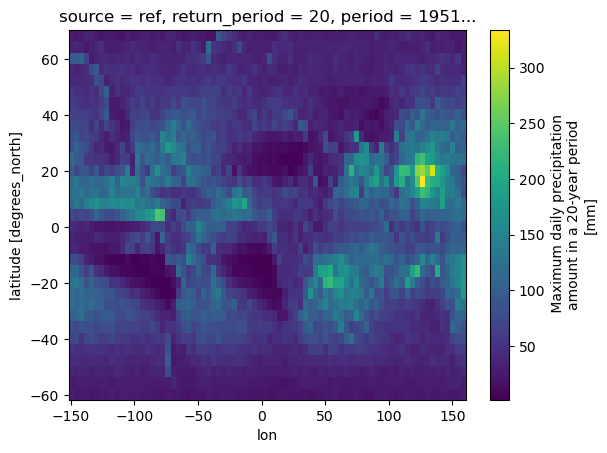

In [23]:
rx1day_ref.plot()

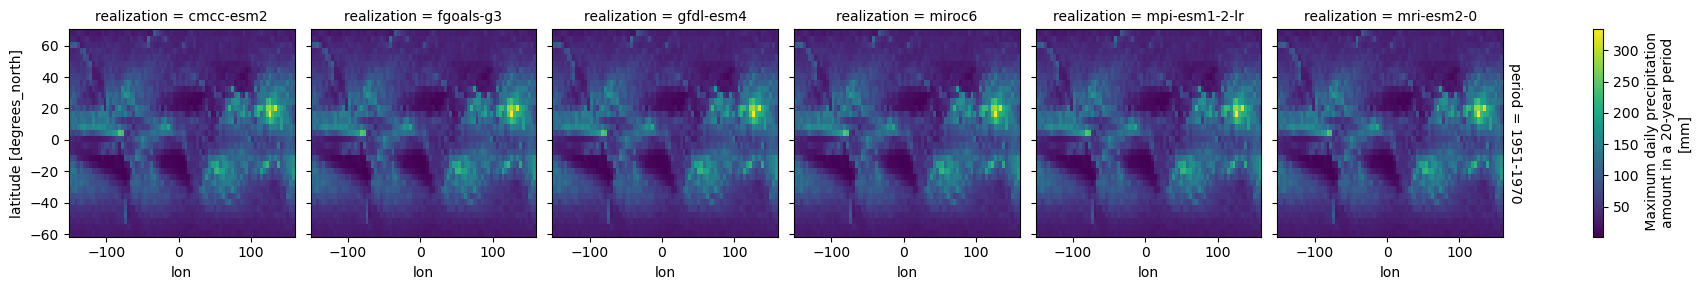

In [24]:
rx1day_hist.plot(col='realization', row='period')

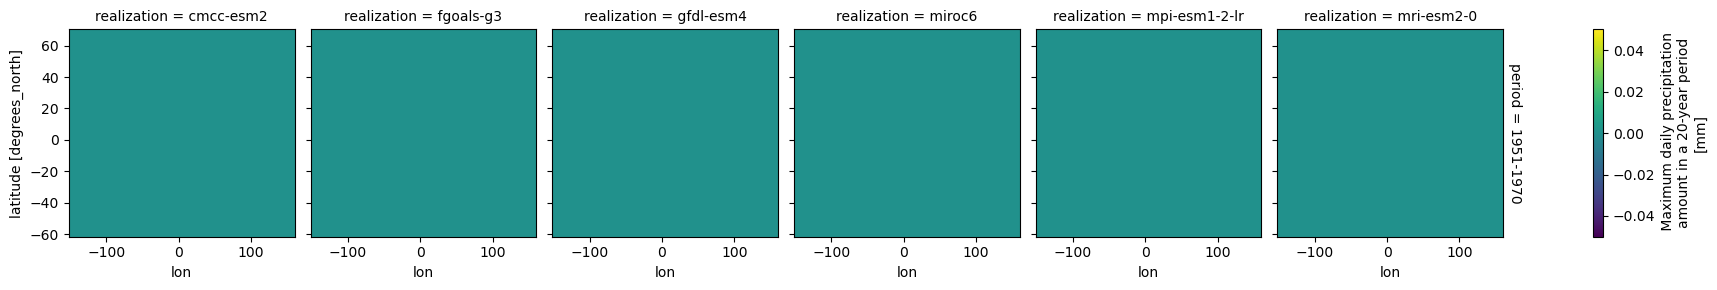

In [25]:
(rx1day_hist-rx1day_ref).plot(col='realization', row='period')

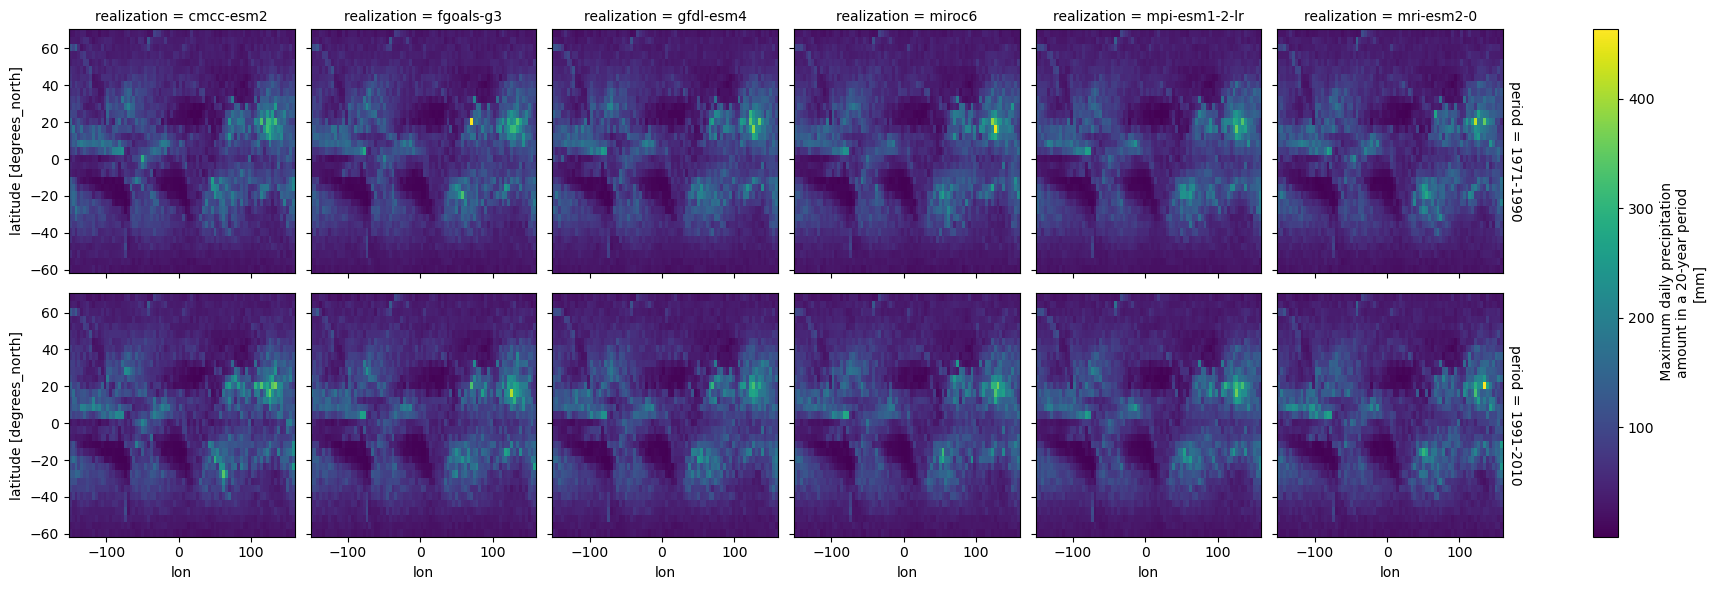

In [26]:
(rx1day_fut).plot(col='realization', row='period')

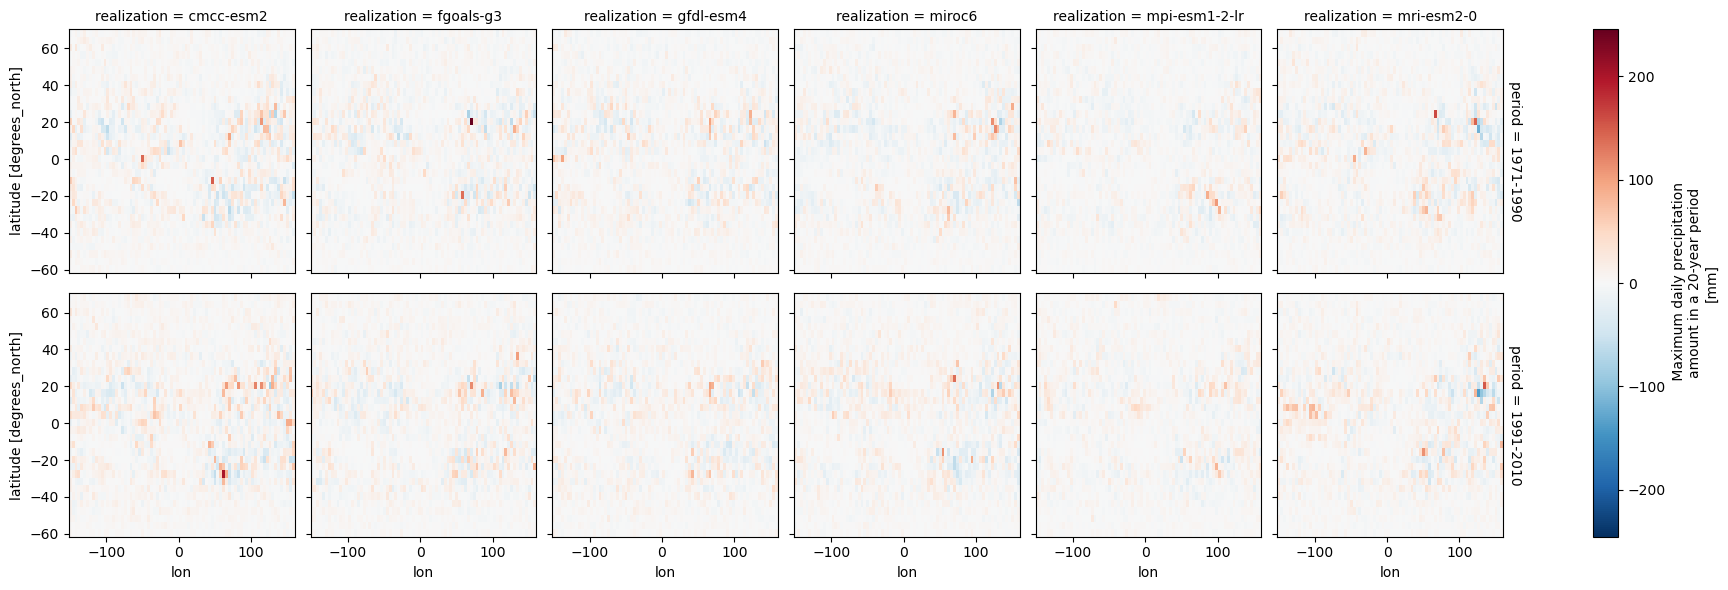

In [27]:
(rx1day_fut-rx1day_hist.isel(period=0)).plot(col='realization', row='period')

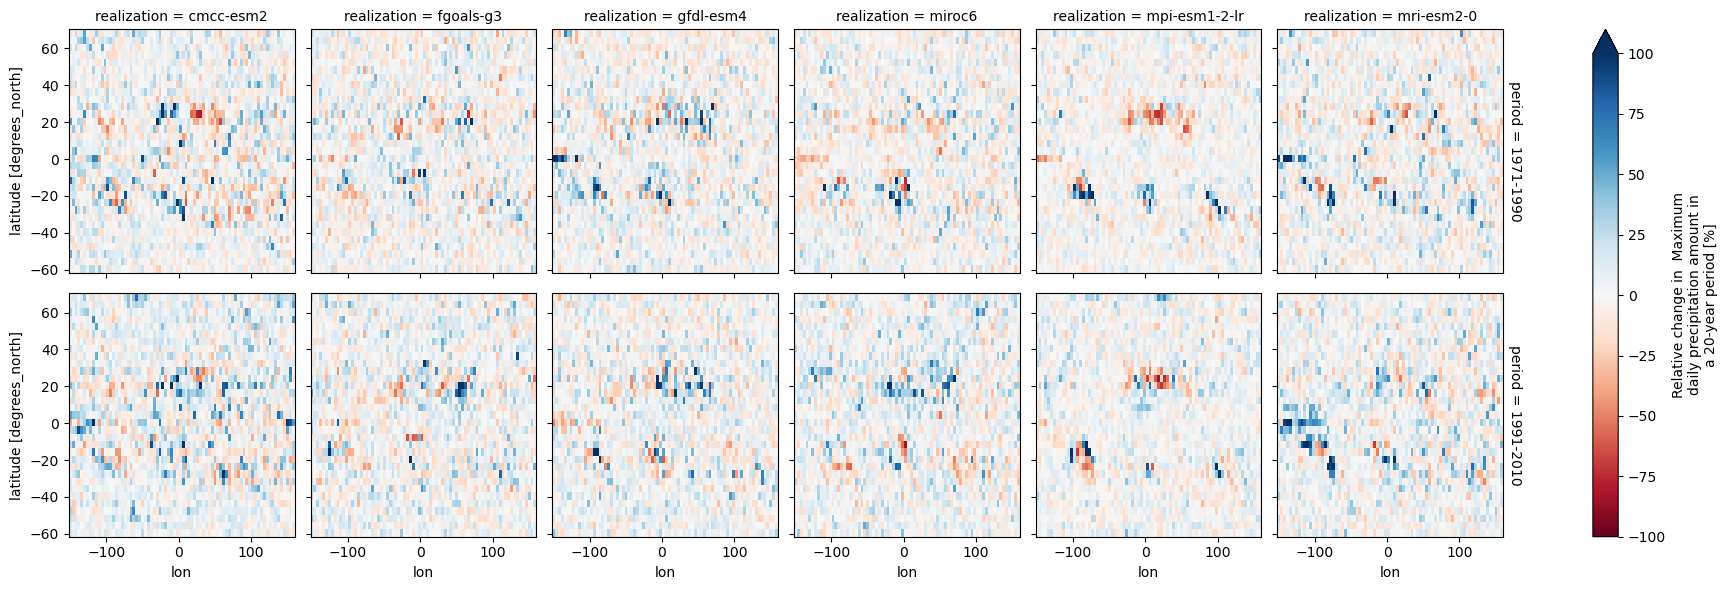

In [28]:
(rx1day_delta).plot(col='realization', row='period', vmin=-100, vmax=100, cmap='RdBu')

## TX30

In [ ]:
tasmax_hist, tasmax_fut = get_refhistfut_quick('tasmax', folder = 'era5-cmip6_exp_ens',)

tasmax_ref = tasmax_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
tasmax_model = xr.concat([tasmax_hist.sel(source='simu'), tasmax_fut.sel(source='simu')], dim='time').chunk({'time': -1})
#tasmax_model

In [ ]:
# Initialize class instance
ids = IndicatorDeltaScaling(
    hist_period=['1951', '1970'],
    fut_period=[['1971', '1990'], ['1991', '2010']]
)

In [32]:
# Compute TX30 using xclim indicator function and corrected indicators
tx30_ref, tx30_hist, tx30_fut, tx30_delta = ids.compute_indicator(
    indicator_func=xclim.indices.tx_days_above, 
    reference_data = tasmax_ref,
    model_data = tasmax_model,
    thresh = '30 degC',
    freq = 'YS',
    delta_mode='+',
    compute = True,
    correct_threshold = True,
    short_name = 'tx30',
    long_name = 'Number of days above 30ºC',
    units = 'days'
)


[########################################] | 100% Completed | 405.27 ms
[########################################] | 100% Completed | 404.43 ms
[########################################] | 100% Completed | 3.18 ss
[########################################] | 100% Completed | 3.12 ss
[########################################] | 100% Completed | 3.19 sms
[########################################] | 100% Completed | 3.20 ss


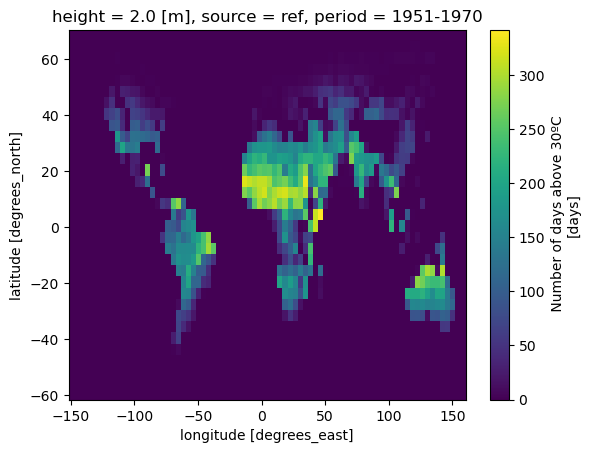

In [33]:
tx30_ref.plot()

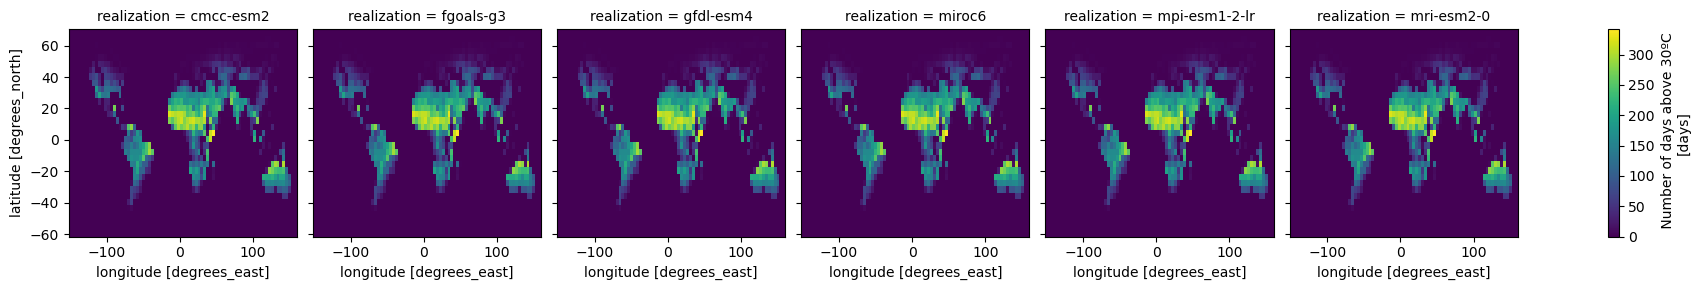

In [34]:
tx30_hist.plot(col='realization')

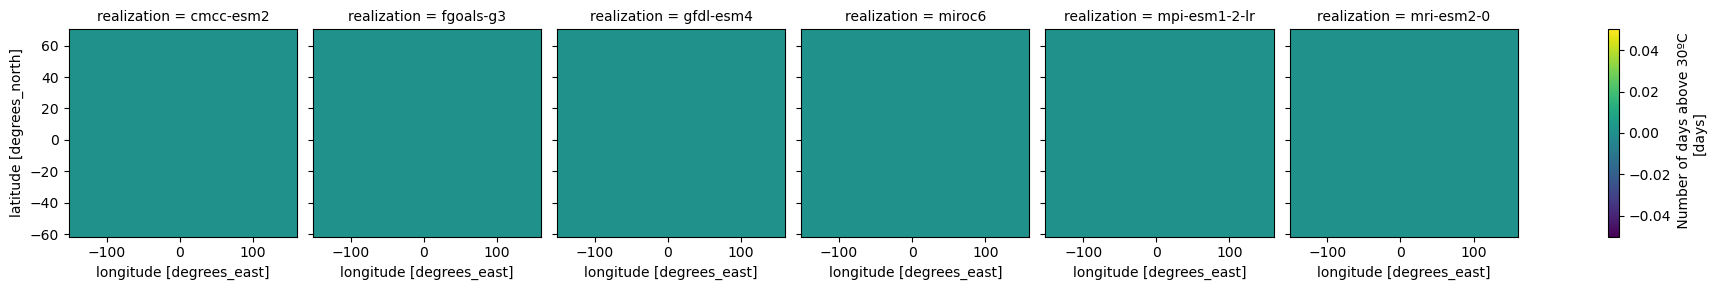

In [35]:
(tx30_hist-tx30_ref).plot(col='realization')

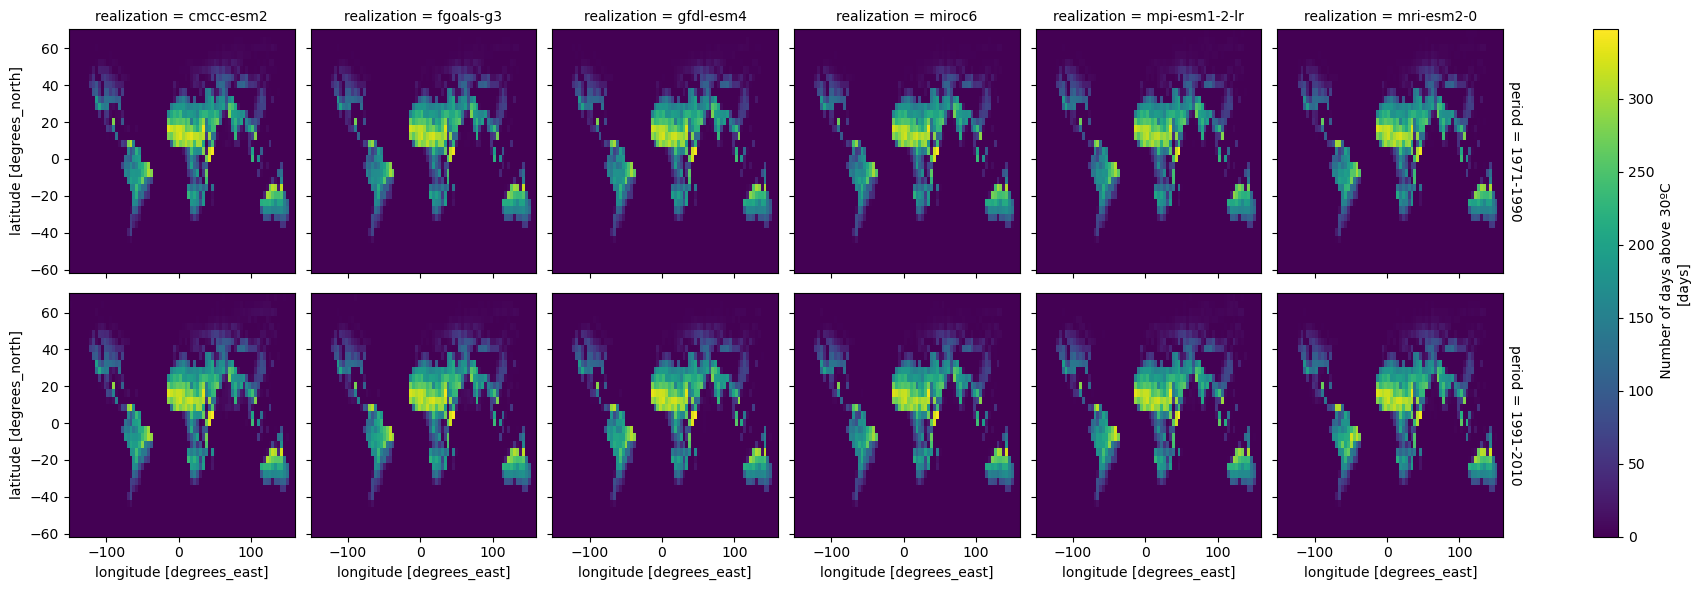

In [36]:
(tx30_fut).plot(col='realization', row='period')

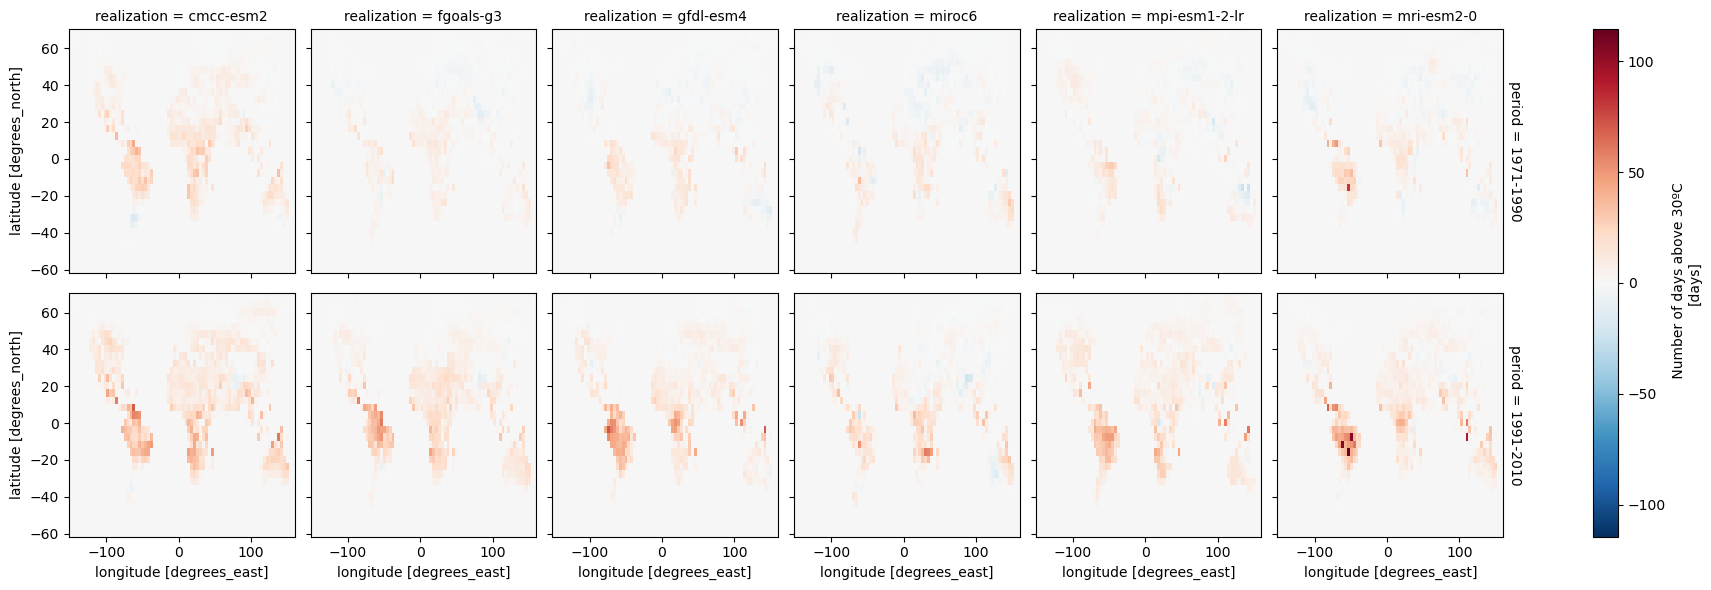

In [37]:
(tx30_fut-tx30_hist.isel(period=0)).plot(col='realization', row='period')

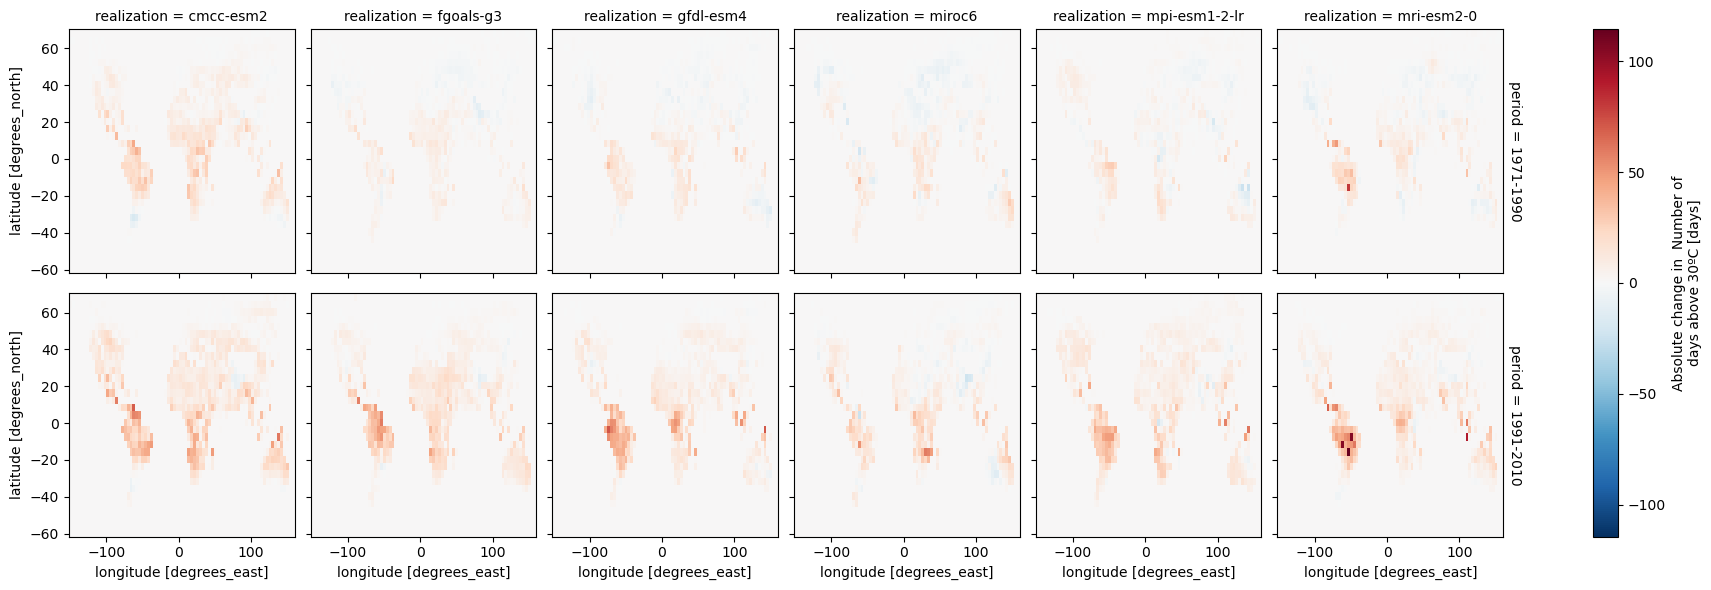

In [38]:
(tx30_delta).plot(col='realization', row='period')

## CDD

In [ ]:
pr_hist, pr_fut = get_refhistfut_quick('pr', folder = 'era5-cmip6_exp_ens',)

pr_ref = pr_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
pr_model = xr.concat([pr_hist.sel(source='simu'), pr_fut.sel(source='simu')], dim='time').chunk({'time': -1})
#pr_model

In [ ]:
# Initialize class instance
ids = IndicatorDeltaScaling(
    hist_period=['1951', '1970'],
    fut_period=[['1971', '1990'], ['1991', '2010']]
)

In [41]:
# Compute CDD using xclim indicator function and corrected indicators
cdd_ref, cdd_hist, cdd_fut, cdd_delta = ids.compute_indicator(
    indicator_func=xclim.indices.maximum_consecutive_dry_days, 
    reference_data = pr_ref,
    model_data = pr_model,
    thresh = '1 mm/day',
    freq = 'YS',
    delta_mode='+',
    compute = True,
    correct_threshold = True,
    short_name = 'cdd',
    long_name = 'Maximum consecutive number of dry days',
    units = 'days'
)

[########################################] | 100% Completed | 410.31 ms
[########################################] | 100% Completed | 411.93 ms
[########################################] | 100% Completed | 3.19 ss
[########################################] | 100% Completed | 3.08 ss
[########################################] | 100% Completed | 3.28 ss
[########################################] | 100% Completed | 3.08 ss


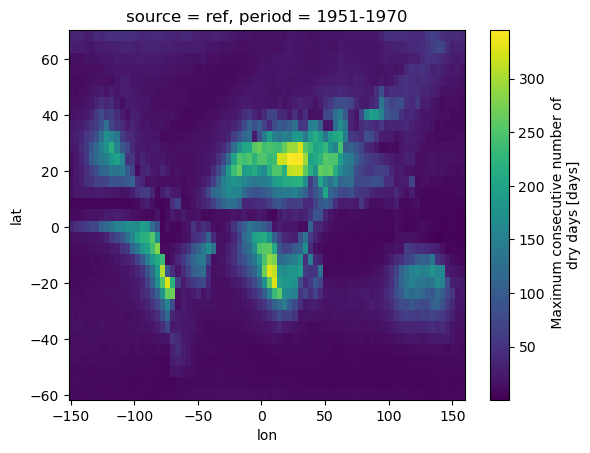

In [42]:
cdd_ref.plot()

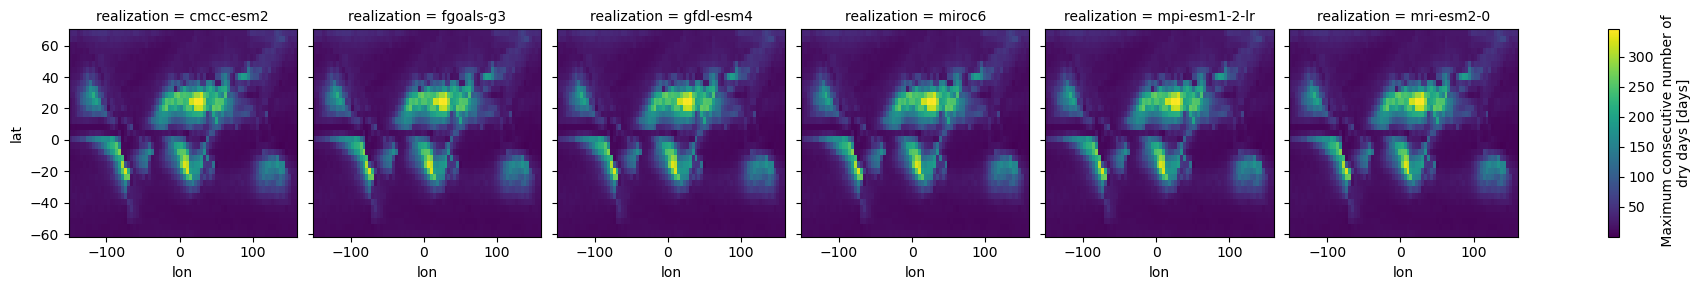

In [43]:
cdd_hist.plot(col='realization')

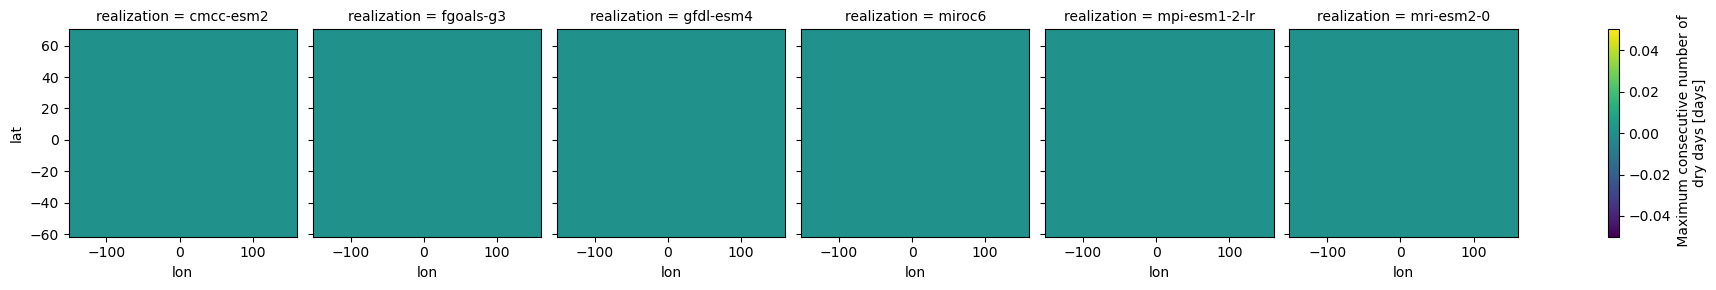

In [44]:
(cdd_hist-cdd_ref).plot(col='realization')

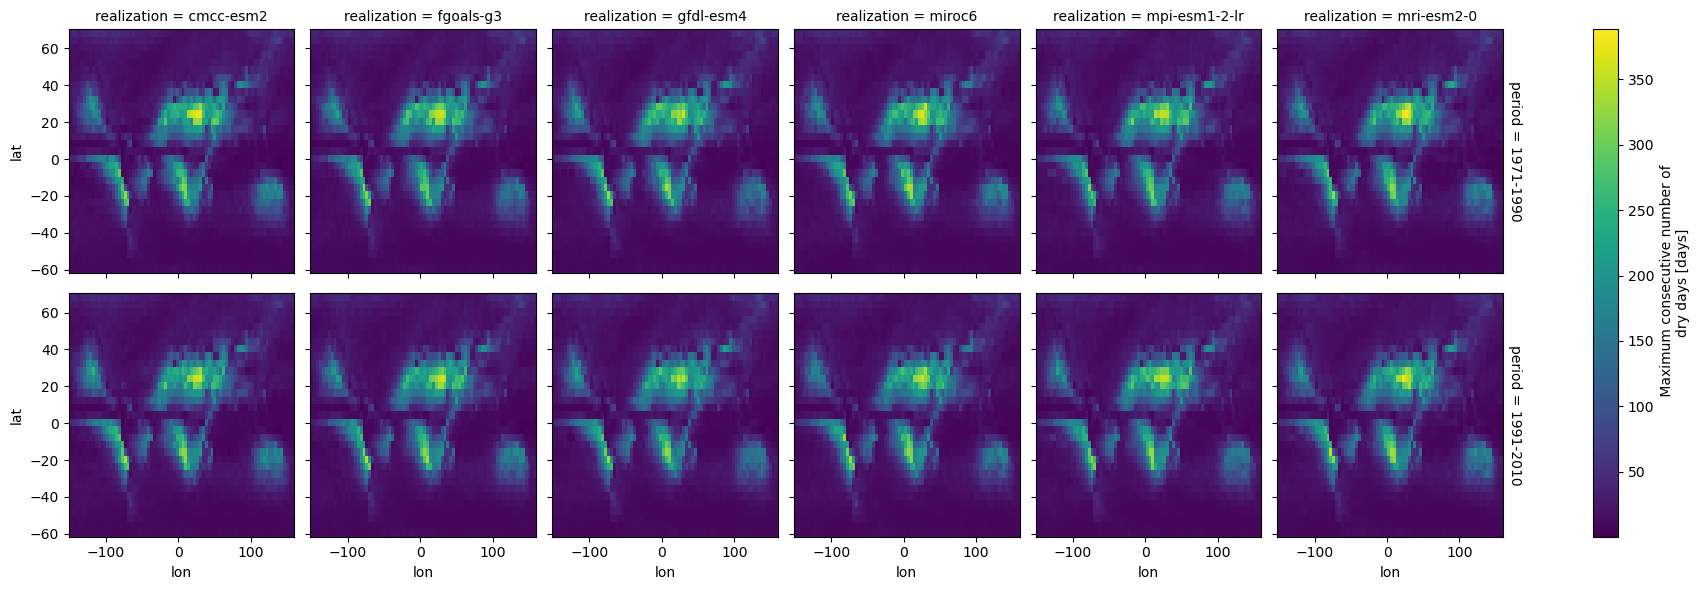

In [45]:
(cdd_fut).plot(col='realization', row='period')

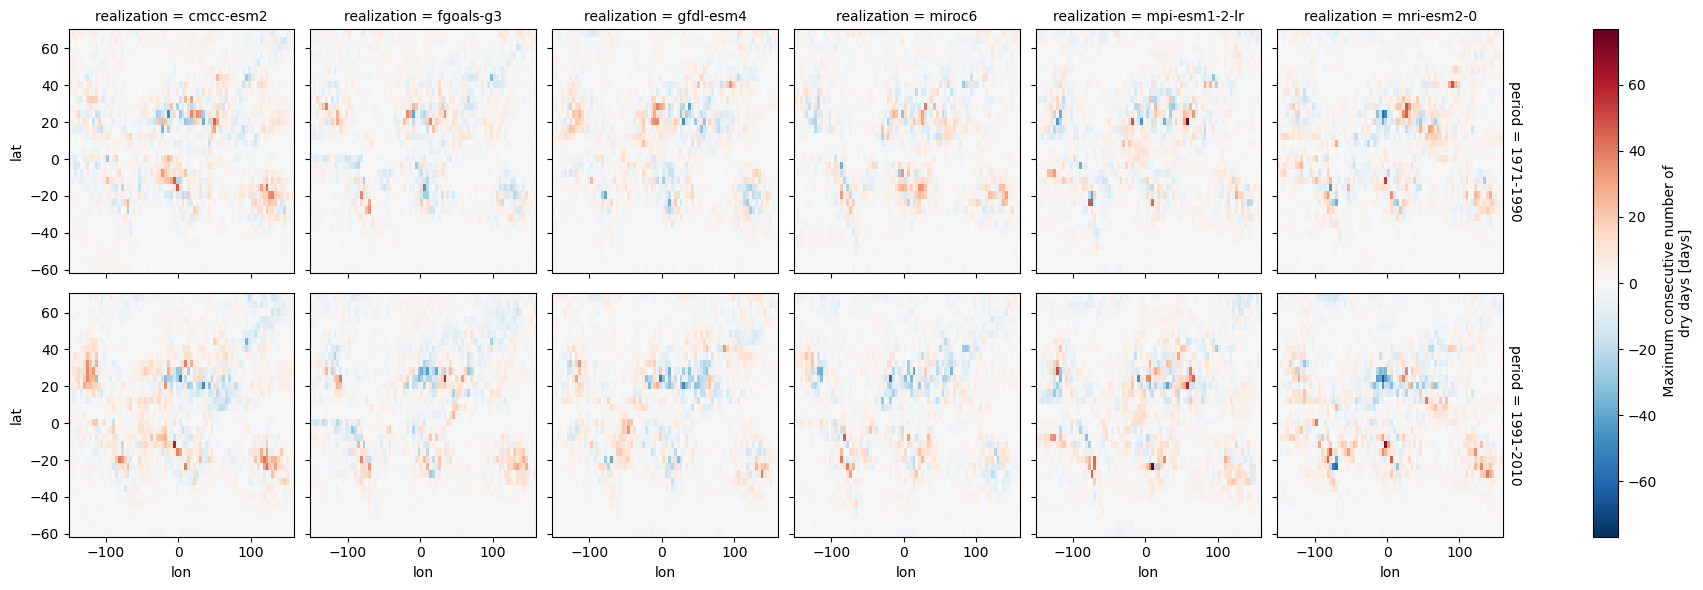

In [46]:
(cdd_fut-cdd_hist.isel(period=0)).plot(col='realization', row='period')

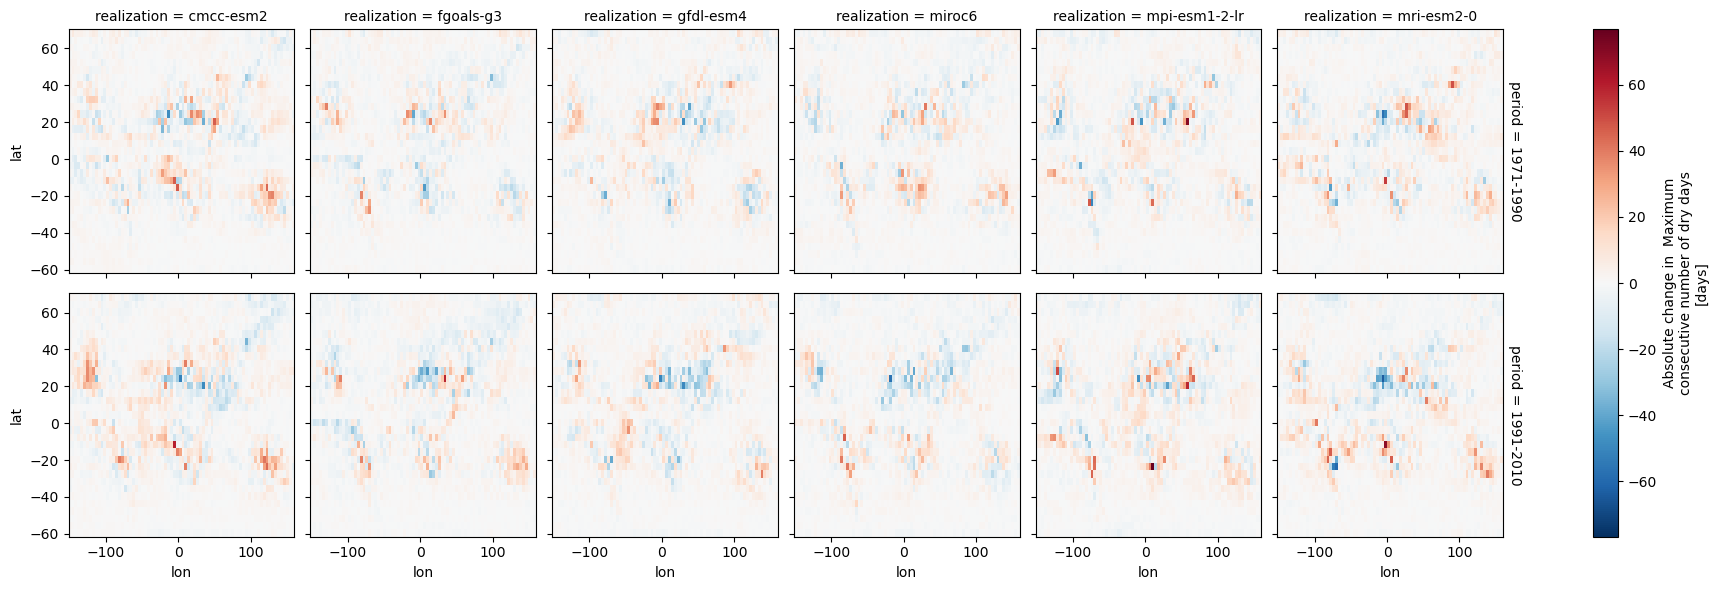

In [47]:
cdd_delta.plot(col='realization', row='period')

## WPD

In [ ]:
wind_hist, wind_fut = get_refhistfut_quick('wind', folder = 'era5-cmip6_exp_ens',)

wind_ref = wind_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
wind_model = xr.concat([wind_hist.sel(source='simu'), wind_fut.sel(source='simu')], dim='time').chunk({'time': -1})


In [ ]:
# Initialize class instance
ids = IndicatorDeltaScaling(
    hist_period=['1951', '1970'],
    fut_period=[['1971', '1990'], ['1991', '2010']]
)

In [50]:
from xids.indicators import get_windpowerdensity

# Compute CDD using xclim indicator function and corrected indicators
wpd_ref, wpd_hist, wpd_fut, wpd_delta = ids.compute_indicator(
    indicator_func=get_windpowerdensity, 
    reference_data = wind_ref,
    model_data = wind_model,
    freq = 'YS',
    delta_mode='*',
    compute = True,
    short_name = 'wpd',
    long_name = 'Wind Power Density',
    units = 'W/m2',
    delta_factor_limit = 5,
)

[########################################] | 100% Completed | 306.61 ms
[########################################] | 100% Completed | 201.87 ms
[########################################] | 100% Completed | 930.75 ms
For some locations, the Delta Change Factor has been limited to 5x.
[########################################] | 100% Completed | 937.04 ms
For some locations, the Delta Change Factor has been limited to 5x.
[########################################] | 100% Completed | 911.70 ms
[########################################] | 100% Completed | 922.07 ms


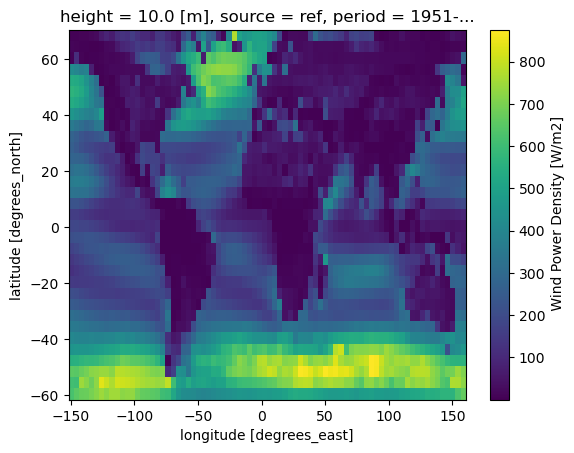

In [51]:
wpd_ref.plot()

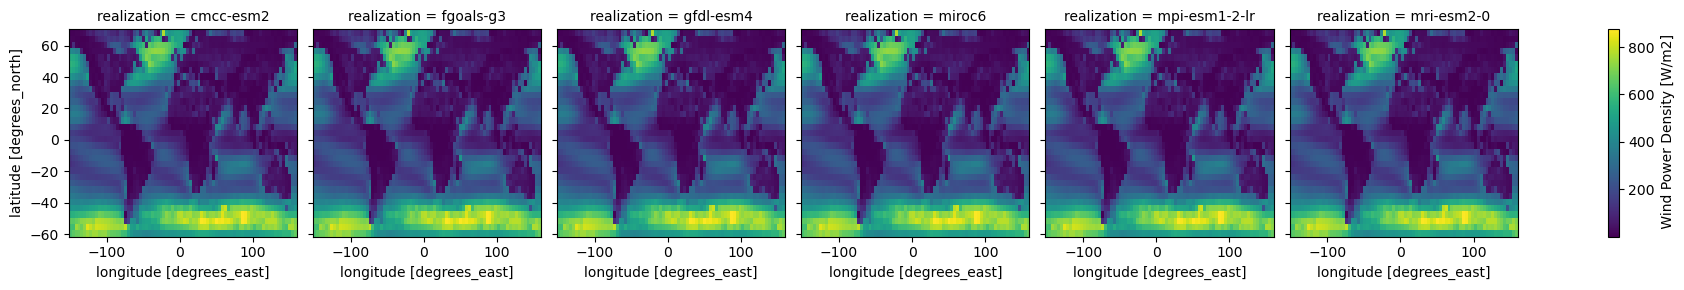

In [52]:
wpd_hist.plot(col='realization')

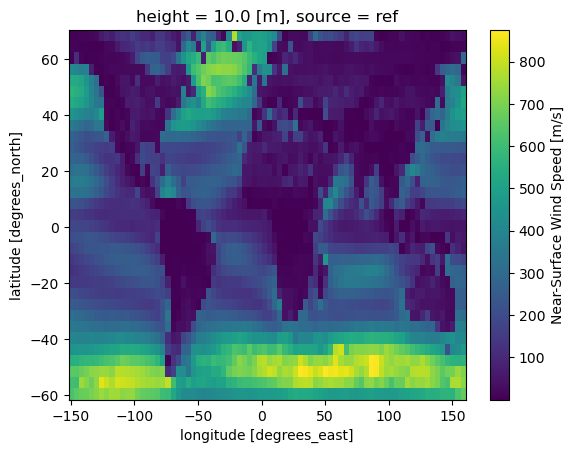

In [53]:
wpd_fut0 = get_windpowerdensity(wind_ref.sel(time=slice('1951','1970'))).mean('time')
wpd_fut0.plot()

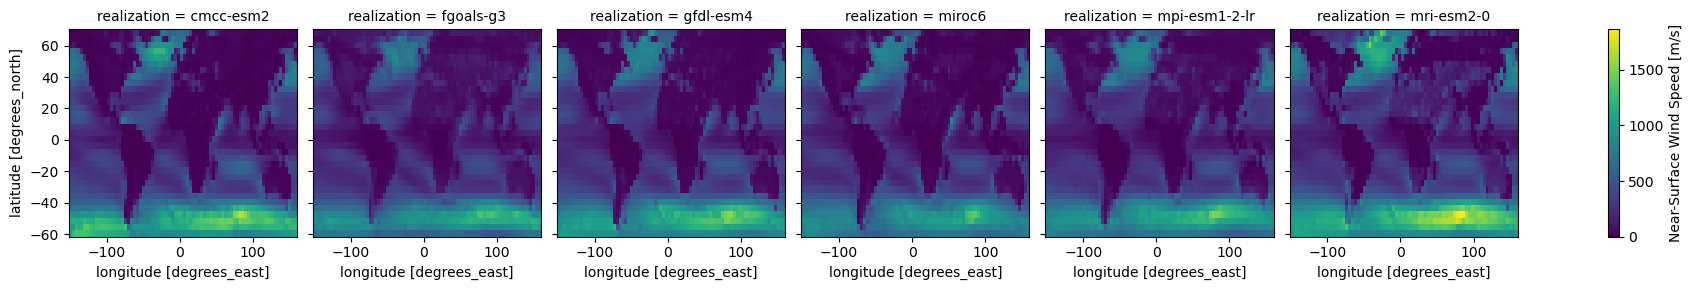

In [54]:
wpd_fut0 = get_windpowerdensity(wind_model.sel(time=slice('1951','1970'))).mean('time')
wpd_fut0.plot(col='realization',)

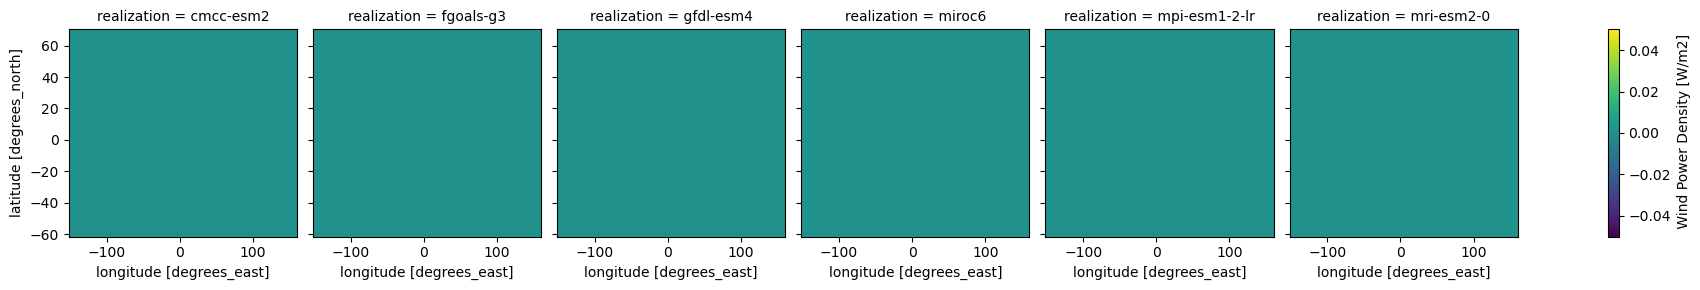

In [55]:
(wpd_hist-wpd_ref).plot(col='realization')

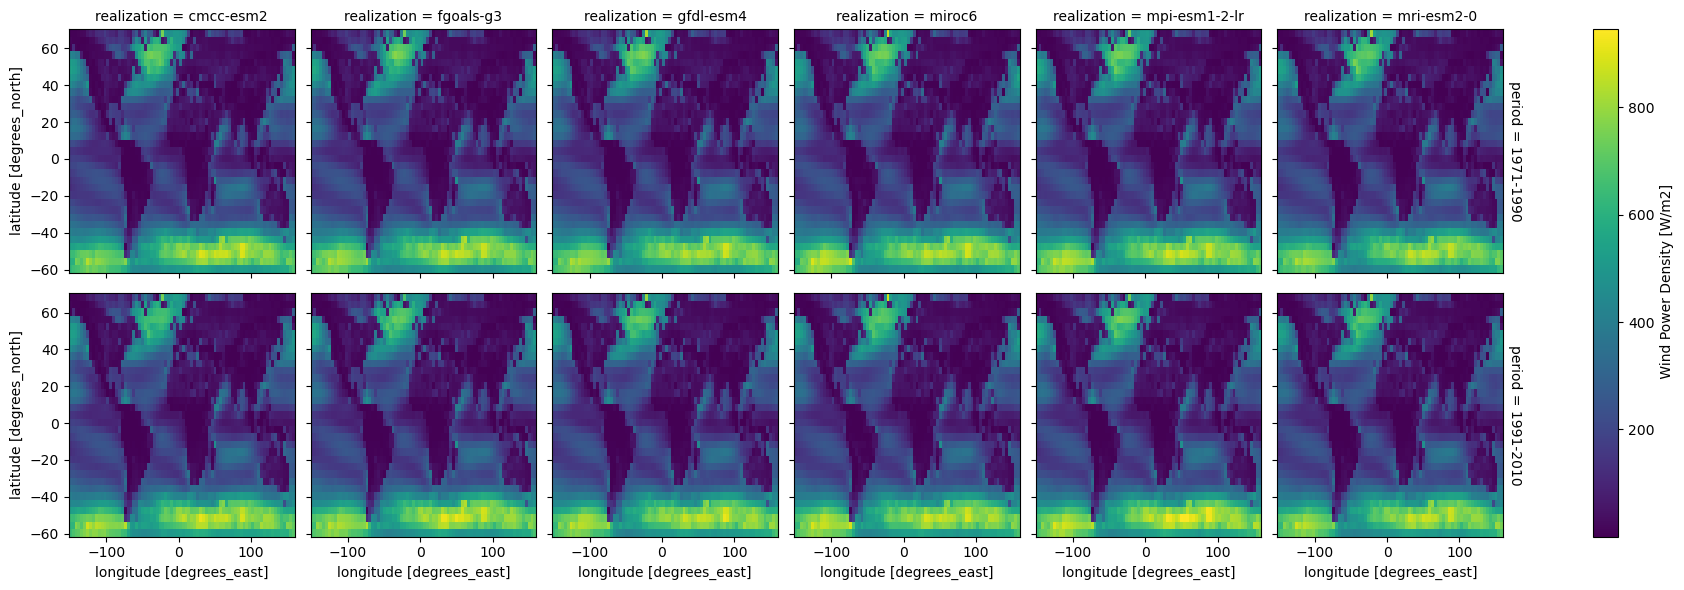

In [56]:
(wpd_fut).plot(col='realization', row='period')

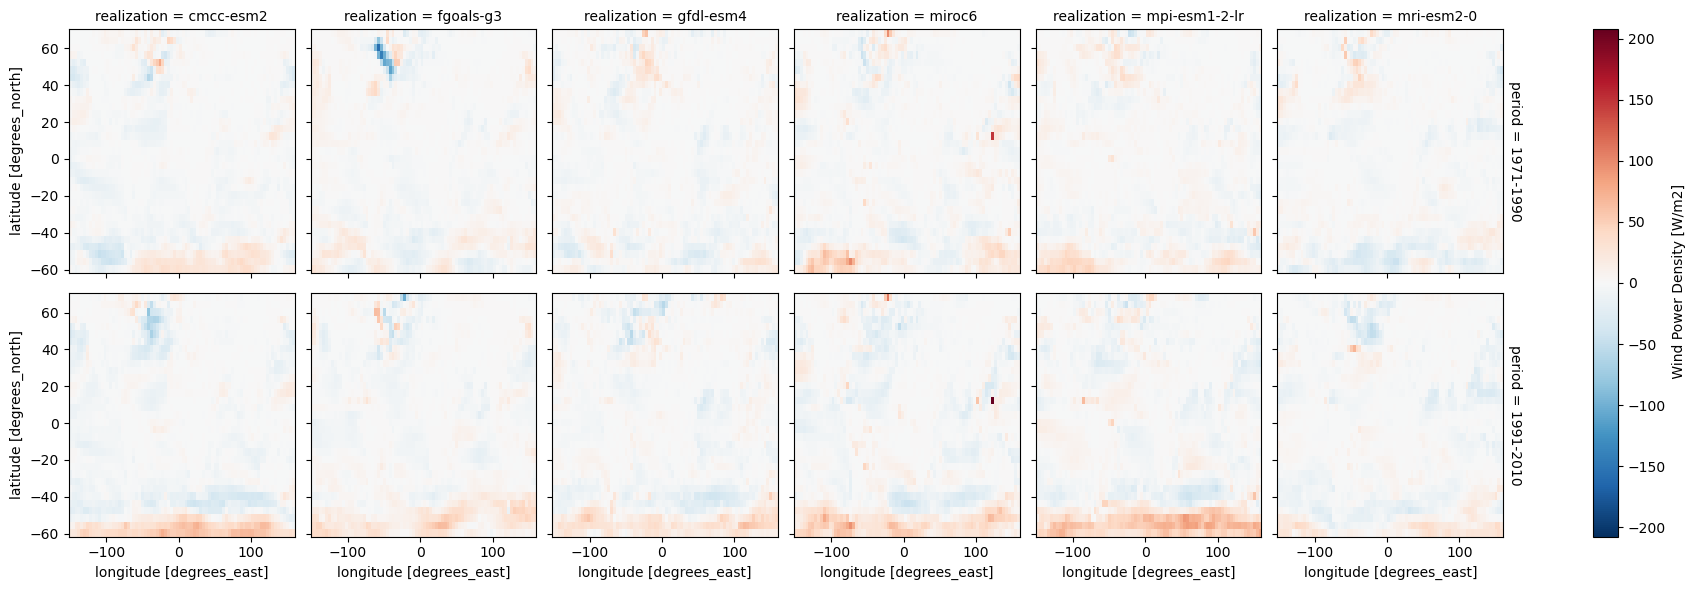

In [57]:
(wpd_fut-wpd_hist.isel(period=0)).plot(col='realization', row='period')

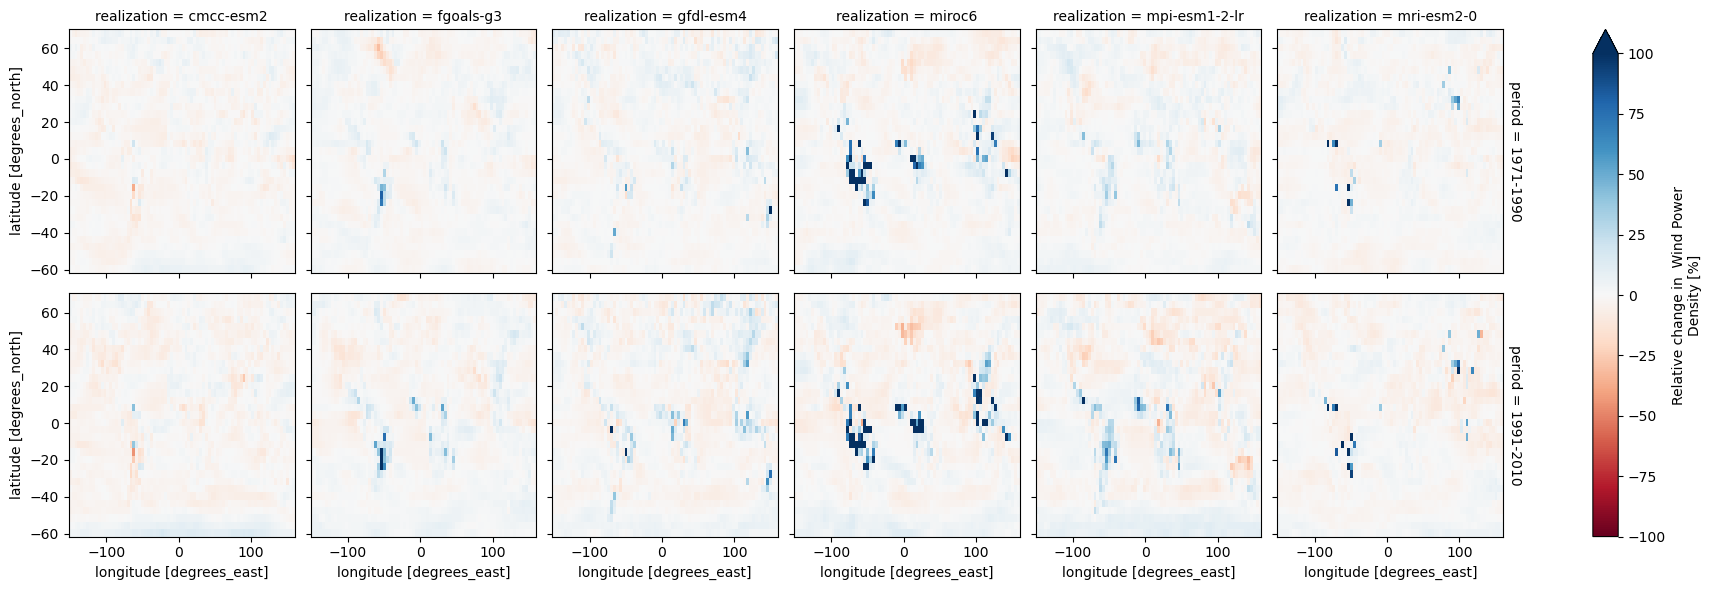

In [58]:
(wpd_delta).plot(col='realization', row='period', vmin = -100, vmax=100, cmap='RdBu')

## FWI90p

In [91]:
tas_hist, tas_fut = get_refhistfut_quick('tas', folder = 'era5-cmip6_exp_ens',)
pr_hist, pr_fut = get_refhistfut_quick('pr', folder = 'era5-cmip6_exp_ens',)
wind_hist, wind_fut = get_refhistfut_quick('wind', folder = 'era5-cmip6_exp_ens',)
hurs_hist, hurs_fut = get_refhistfut_quick('hurs', folder = 'era5-cmip6_exp_ens',)


tas_ref = tas_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
tas_model = xr.concat([tas_hist.sel(source='simu'), tas_fut.sel(source='simu')], dim='time').chunk({'time': -1})


pr_ref = pr_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
pr_model = xr.concat([pr_hist.sel(source='simu'), pr_fut.sel(source='simu')], dim='time').chunk({'time': -1})


wind_ref = wind_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
wind_model = xr.concat([wind_hist.sel(source='simu'), wind_fut.sel(source='simu')], dim='time').chunk({'time': -1})


hurs_ref = hurs_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
hurs_model = xr.concat([hurs_hist.sel(source='simu'), hurs_fut.sel(source='simu')], dim='time').chunk({'time': -1})


In [131]:
fwi_ref = xclim.indices.fire.cffwis_indices(tas_model, pr_model, wind_model, hurs_model, lat=tas_ref.lat)[-1]
fwi_model = xclim.indices.fire.cffwis_indices(tas_model, pr_model, wind_model, hurs_model, lat=tas_model.lat)[-1]

In [ ]:
# Initialize class instance
ids = IndicatorDeltaScaling(
    hist_period=['1951', '1970'],
    fut_period=[['1971', '1990'], ['1991', '2010']]
)

In [ ]:

fwi90p_ref, fwi90p_hist, fwi90p_fut, fwi90p_delta = ids.compute_indicator(
    indicator_func=indicators.get_percentile_value,
    reference_data = fwi_ref,
    model_data = fwi_model,
    quantile = 0.9,
    freq = 'YS',
    delta_mode='+',
    short_name = 'FWI90p',
    long_name = 'Percentile 90th of annual Fire Weather Index',
    units = '',
    delta_factor_limit = None,
)

[########################################] | 100% Completed | 5.85 sms
[########################################] | 100% Completed | 5.24 sms
[########################################] | 100% Completed | 72.24 s
[########################################] | 100% Completed | 71.56 s
[########################################] | 100% Completed | 82.59 s
[########################################] | 100% Completed | 71.60 ss


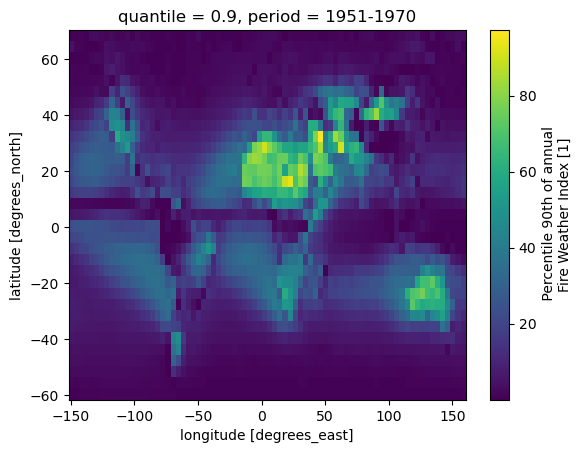

In [ ]:
fwi90p_ref.plot()

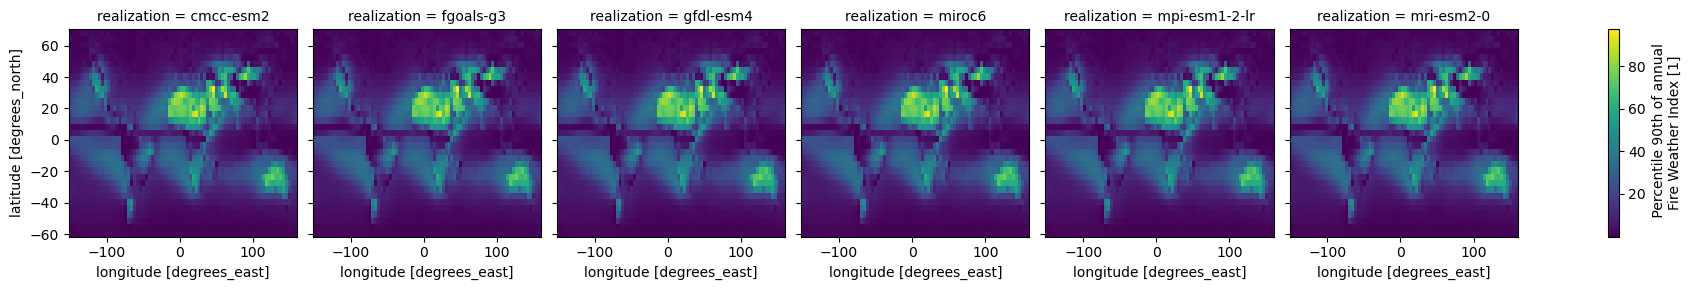

In [ ]:
fwi90p_hist.plot(col='realization')

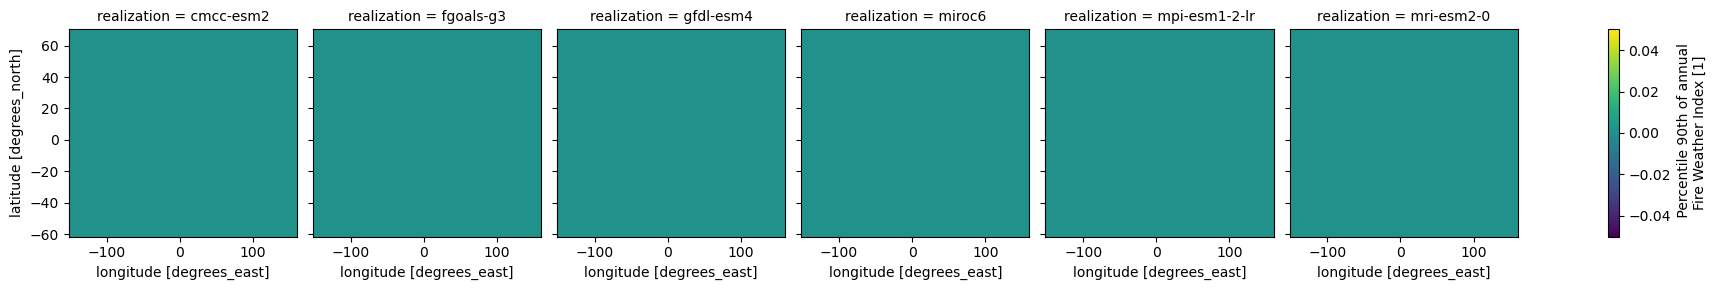

In [ ]:
(fwi90p_hist-fwi90p_ref).plot(col='realization')

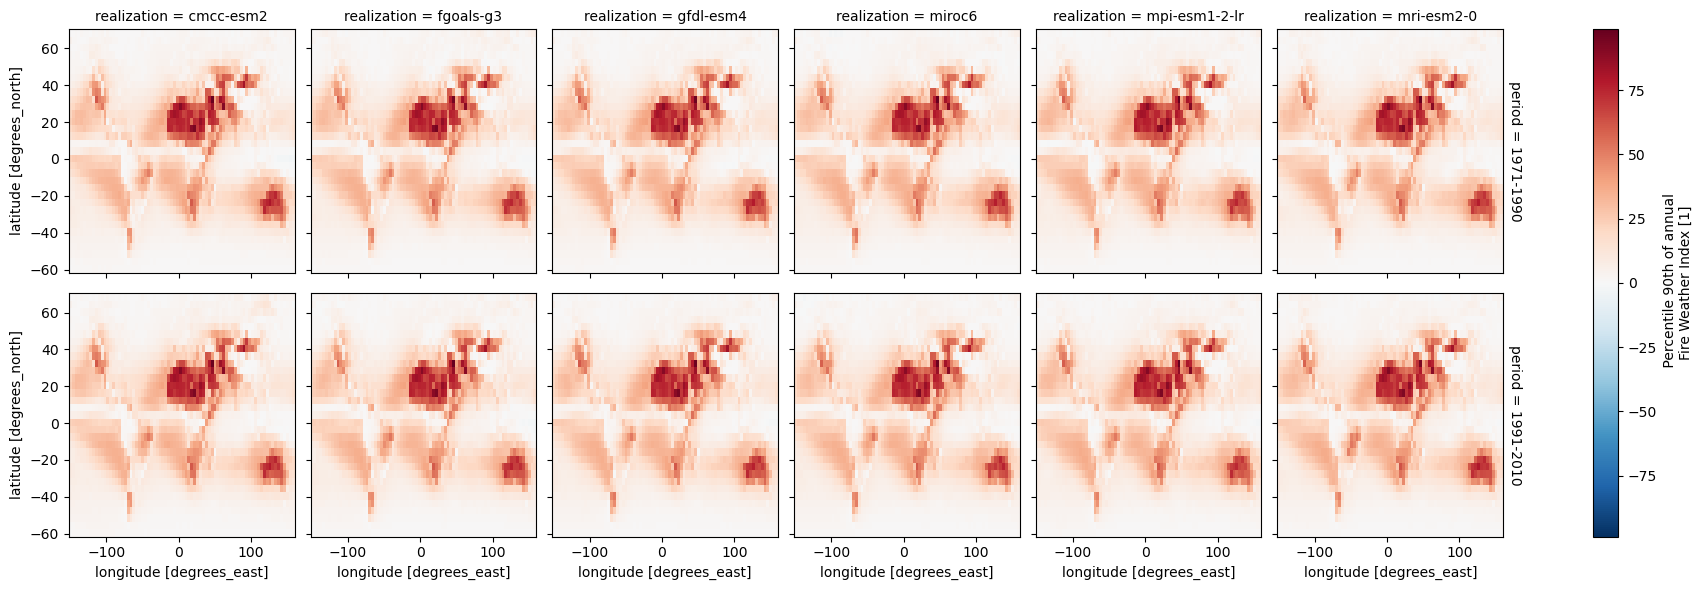

In [ ]:
fwi90p_fut.plot(col='realization', row='period')

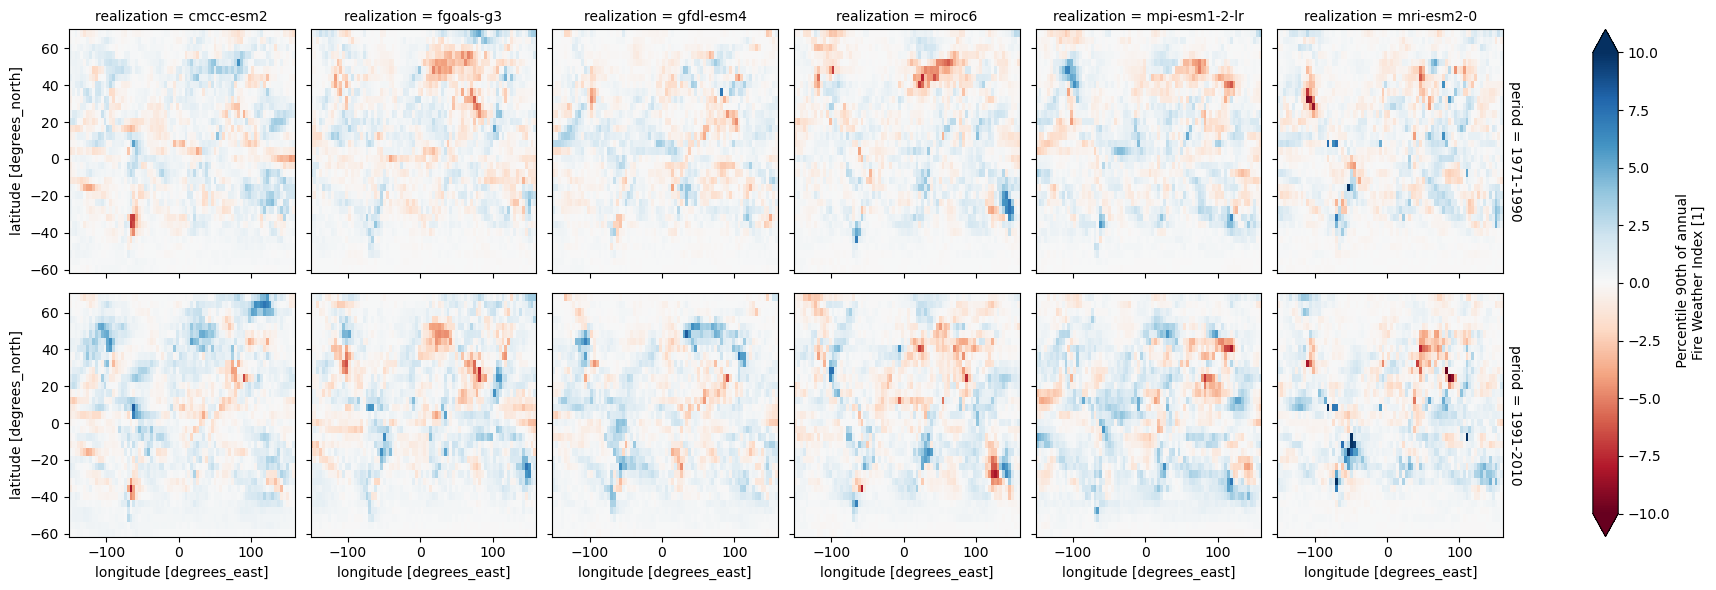

In [ ]:
(fwi90p_fut-fwi90p_hist.isel(period=0)).plot(col='realization', row='period', vmin=-10, vmax=10, cmap='RdBu')

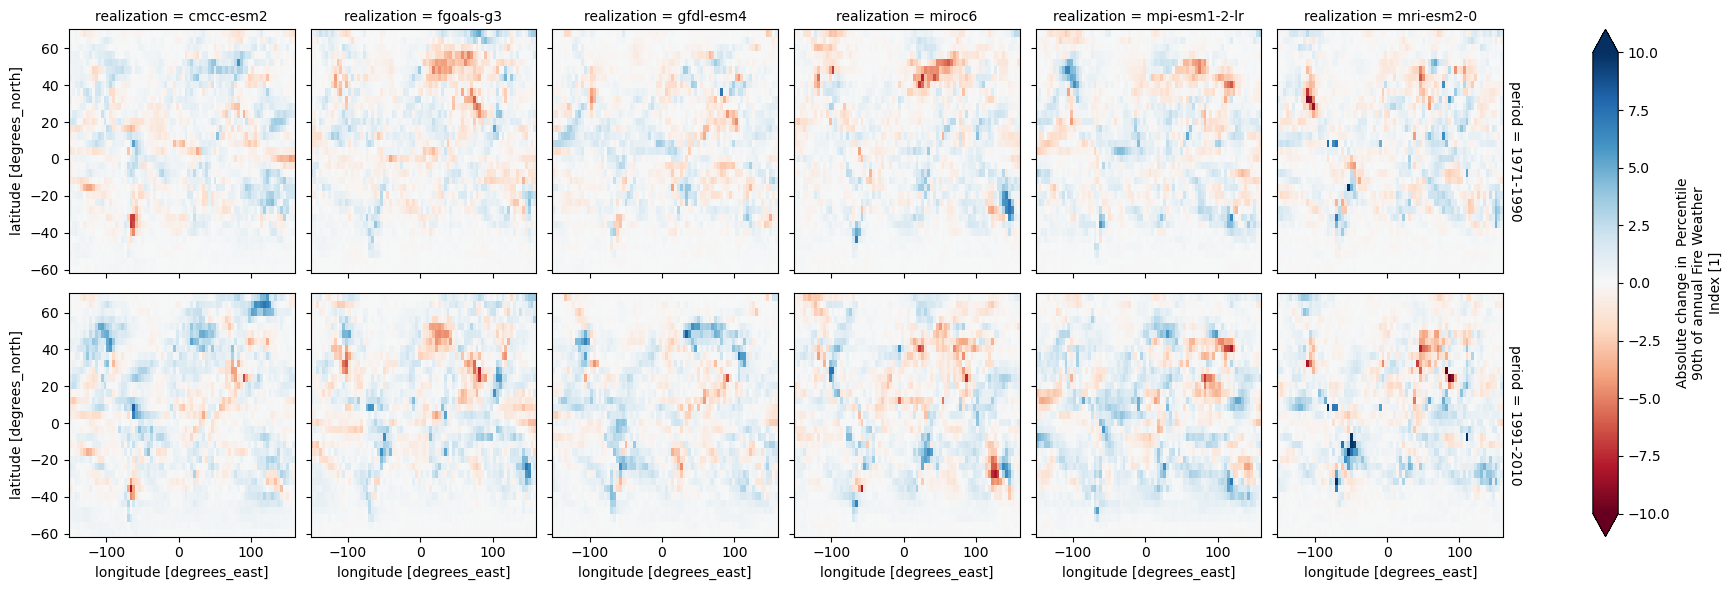

In [ ]:
fwi90p_delta.plot(col='realization', row='period', vmin=-10, vmax=10, cmap='RdBu')

## SPI12

In [99]:
pr_hist, pr_fut = get_refhistfut_quick('pr', folder = 'era5-cmip6_exp_ens',)

pr_ref = pr_hist.sel(source='ref').isel(realization=0).drop_vars('realization')
pr_model = xr.concat([pr_hist.sel(source='simu'), pr_fut.sel(source='simu')], dim='time').chunk({'time': -1})

In [ ]:
spi12_ref = xclim.indices.standardized_precipitation_index(pr_ref, freq='MS', window=12, dist=gam, method='PWM')
spi12_model = xclim.indices.standardized_precipitation_index(pr_model, freq='MS', window=12, dist=gam, method='PWM')

/home/jpena/miniconda3/envs/xr2/lib/python3.13/site-packages/xclim/indices/stats.py:975: UserWarning: The input data is chunked on time dimension and must be fully rechunked to run `fit` on groups . Beware, this operation can significantly increase the number of tasks dask has to handle.
  da, _ = preprocess_standardized_index(da, freq=freq, window=window, **indexer)
/home/jpena/miniconda3/envs/xr2/lib/python3.13/site-packages/xclim/indices/stats.py:975: UserWarning: The input data is chunked on time dimension and must be fully rechunked to run `fit` on groups . Beware, this operation can significantly increase the number of tasks dask has to handle.
  da, _ = preprocess_standardized_index(da, freq=freq, window=window, **indexer)


In [ ]:
# Initialize class instance
ids = IndicatorDeltaScaling(
    hist_period=['1951', '1970'],
    fut_period=[['1971', '1990'], ['1991', '2010']]
)

In [138]:
spi12spell_ref, spi12spell_hist, spi12spell_fut, spi12spell_delta = ids.compute_indicator(
    indicator_func = xclim.indices.generic.spell_length_statistics,
    reference_data = spi12_ref,
    model_data = spi12_model,
    threshold = '-1',
    window = 1,
    win_reducer = 'mean',
    op = '<',
    spell_reducer = 'count',
    freq = '20YS',
    delta_mode='+',
    short_name = 'SPI12spell',
    long_name = 'Mean spell length of 12-month Standardized Precipitation Index',
    units = '',
    delta_factor_limit = None,
)

[########################################] | 100% Completed | 103.46 ms
[########################################] | 100% Completed | 101.25 ms
[########################################] | 100% Completed | 19.31 s
[########################################] | 100% Completed | 18.68 s
[########################################] | 100% Completed | 19.10 s
[########################################] | 100% Completed | 18.59 s


In [144]:
spi12sev_ref, spi12sev_hist, spi12sev_fut, spi12sev_delta = ids.compute_indicator(
    indicator_func = indicators.get_drought_sev,
    reference_data = spi12_ref,
    model_data = spi12_model,
    threshold = -1,
    freq = 'YS',
    delta_mode='+',
    short_name = 'SPI12sev',
    long_name = 'Mean spell severity of 12-month Standardized Precipitation Index',
    units = '',
    delta_factor_limit = None,
)

[########################################] | 100% Completed | 101.91 ms
[########################################] | 100% Completed | 101.66 ms
[########################################] | 100% Completed | 18.23 s
[########################################] | 100% Completed | 18.98 s
[########################################] | 100% Completed | 18.53 s
[########################################] | 100% Completed | 18.52 s


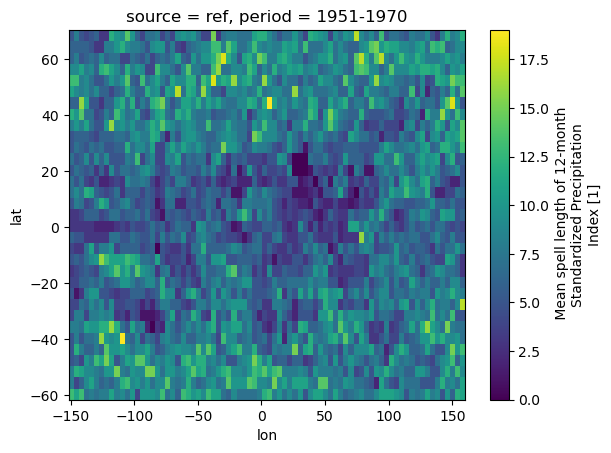

In [139]:
spi12spell_ref.plot()

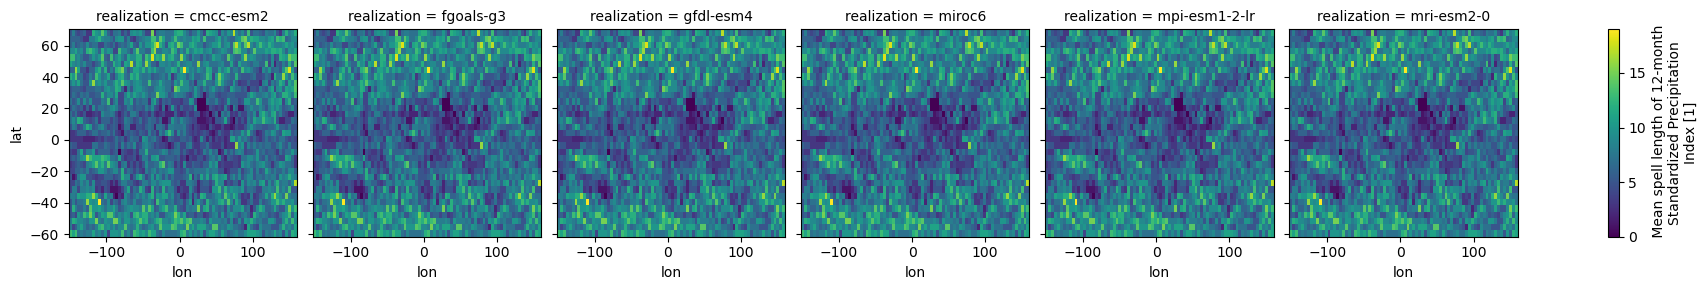

In [140]:
spi12spell_hist.plot(col='realization')

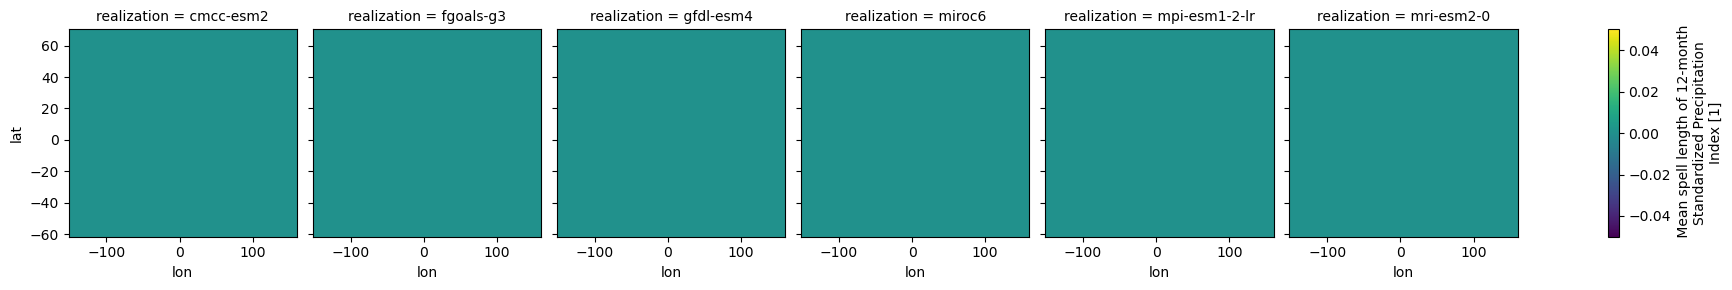

In [141]:
(spi12spell_hist-spi12spell_ref).plot(col='realization')

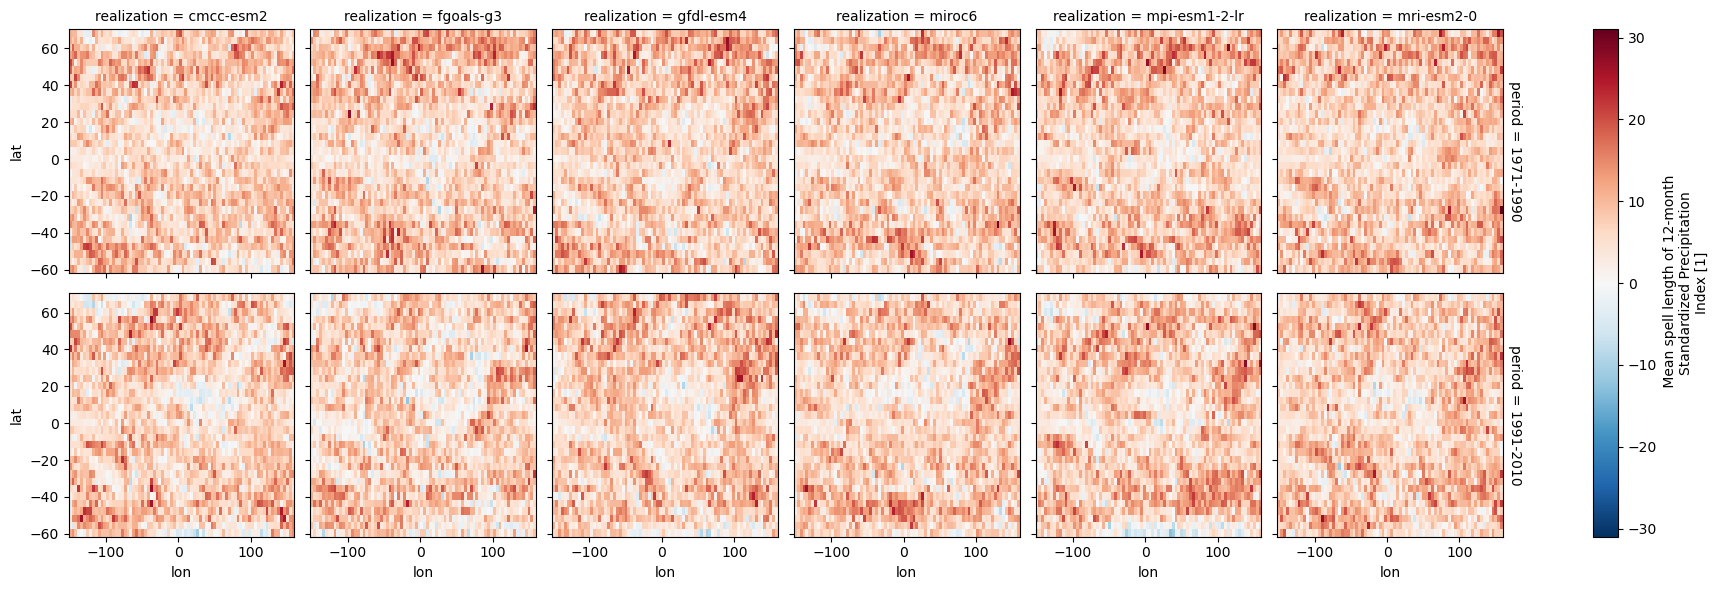

In [143]:
spi12spell_fut.plot(col='realization', row='period')

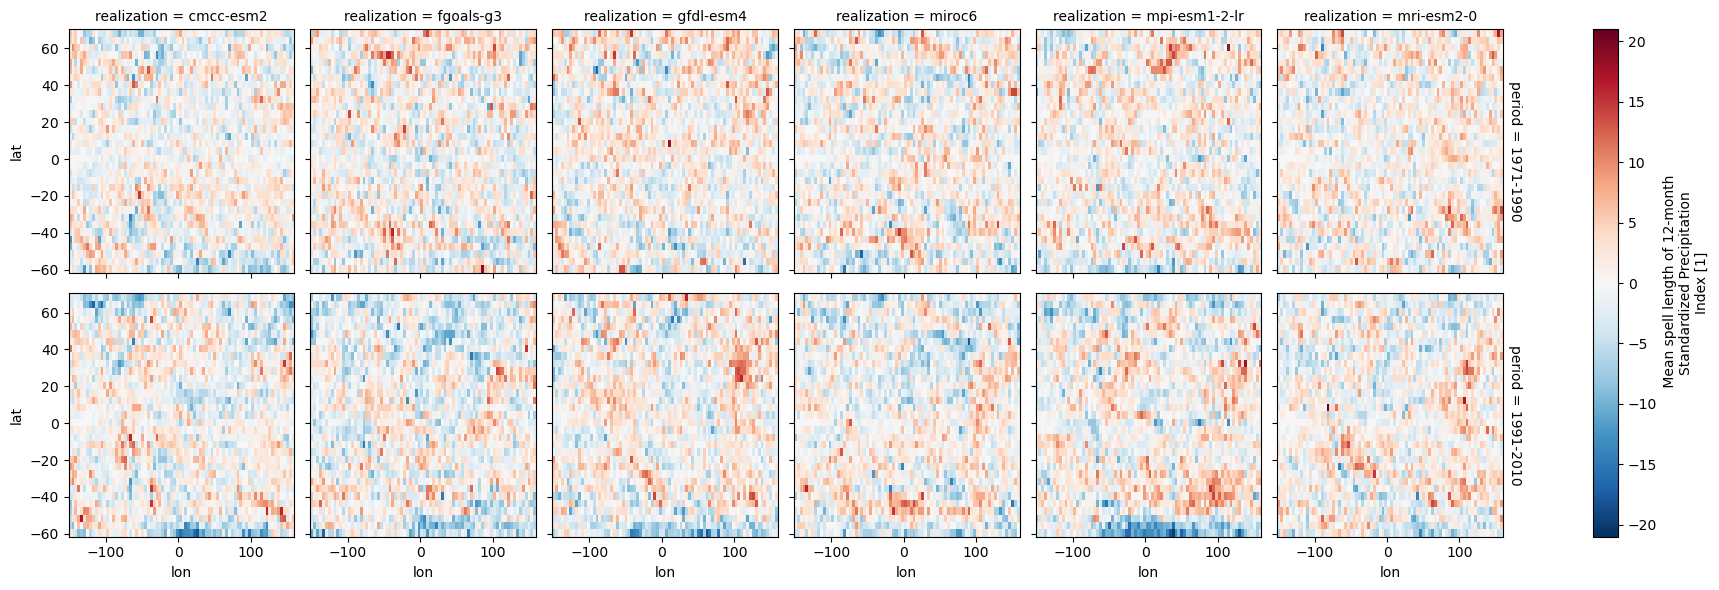

In [142]:
(spi12spell_fut-spi12spell_hist.isel(period=0)).plot(col='realization', row='period')

In [ ]:
spi12sev_ref, spi12sev_hist, spi12sev_fut, spi12sev_delta = ids.compute_indicator(
    indicator_func = indicators.get_drought_sev,
    reference_data = spi12_ref,
    model_data = spi12_model,
    threshold = -1,
    freq = 'YS',
    delta_mode='+',
    short_name = 'SPI12sev',
    long_name = 'Mean spell severity of 12-month Standardized Precipitation Index',
    units = '',
    delta_factor_limit = None,
)

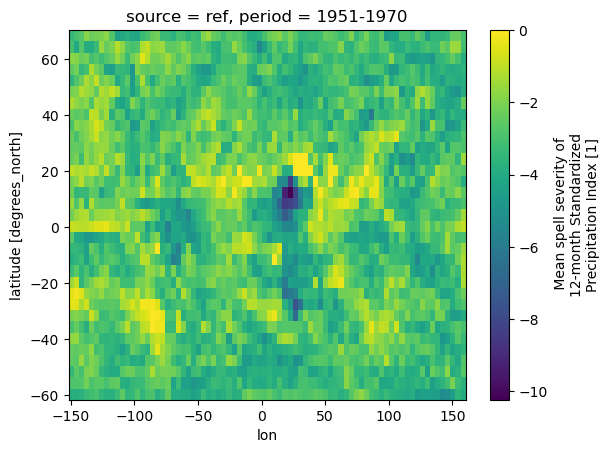

In [145]:
spi12sev_ref.plot()

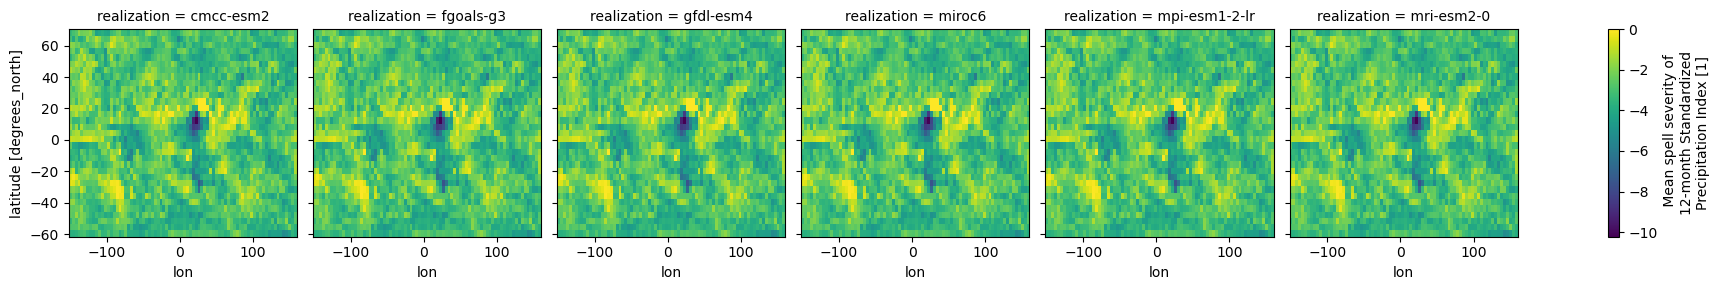

In [146]:
spi12sev_hist.plot(col='realization')

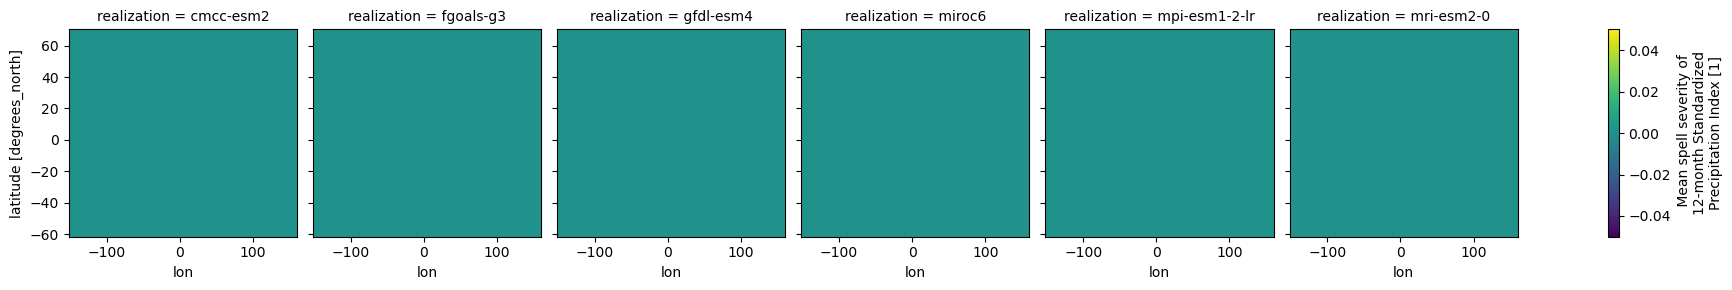

In [147]:
(spi12sev_hist-spi12sev_ref).plot(col='realization')

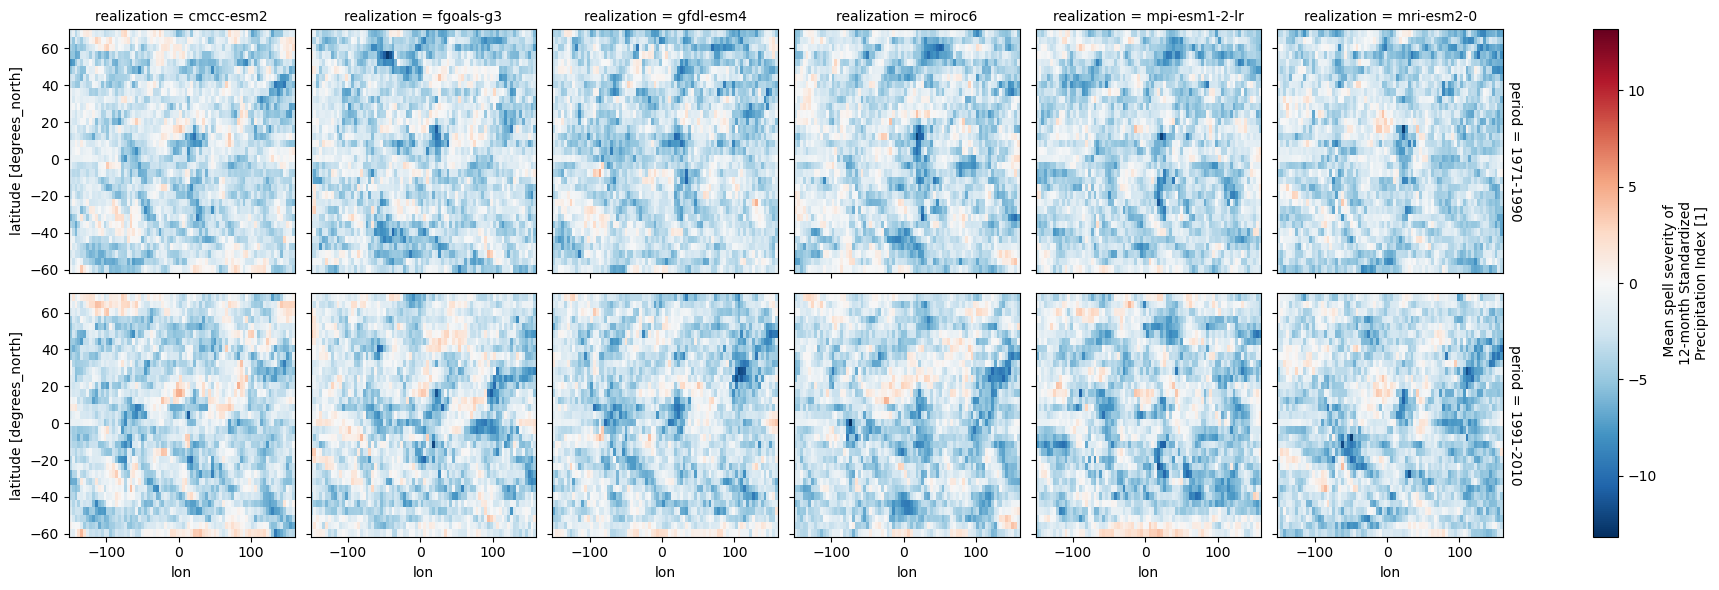

In [148]:
spi12sev_fut.plot(col='realization', row='period')

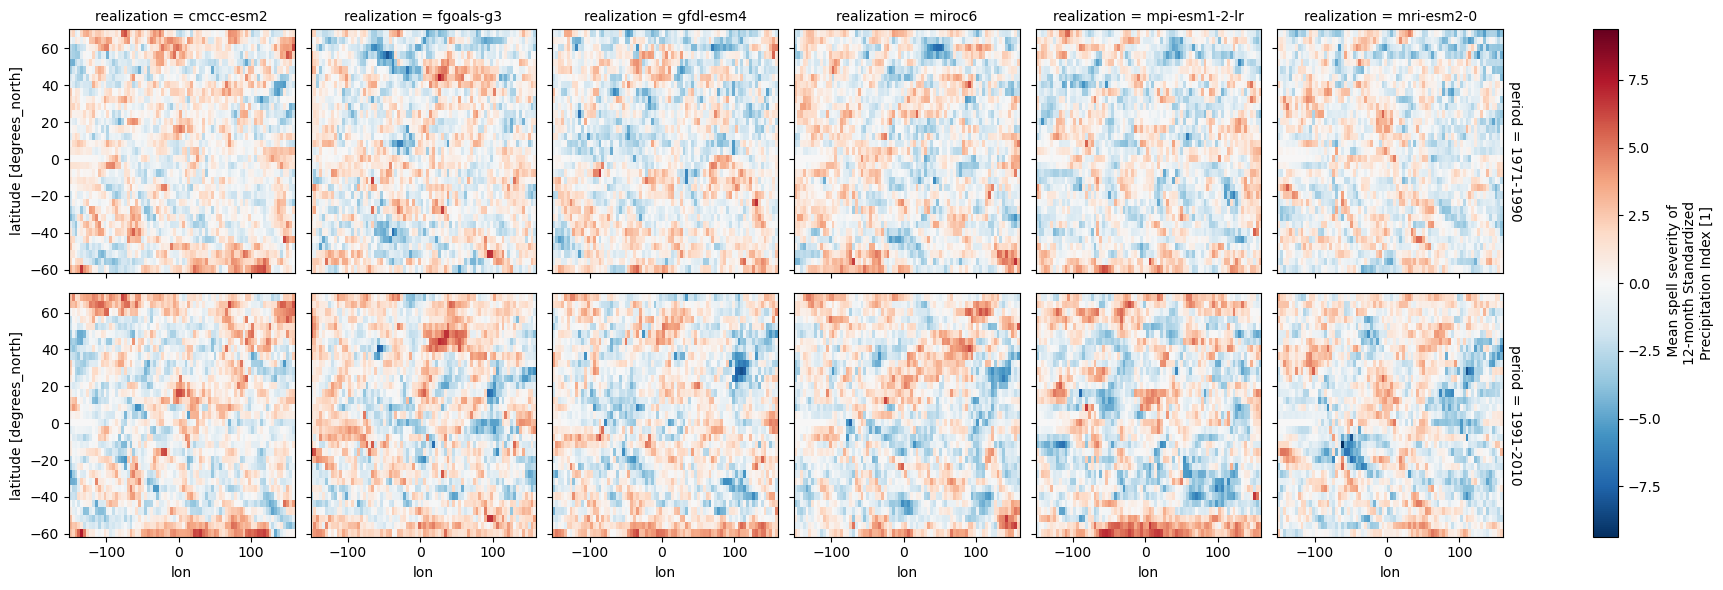

In [149]:
(spi12sev_fut-spi12sev_hist.isel(period=0)).plot(col='realization', row='period')

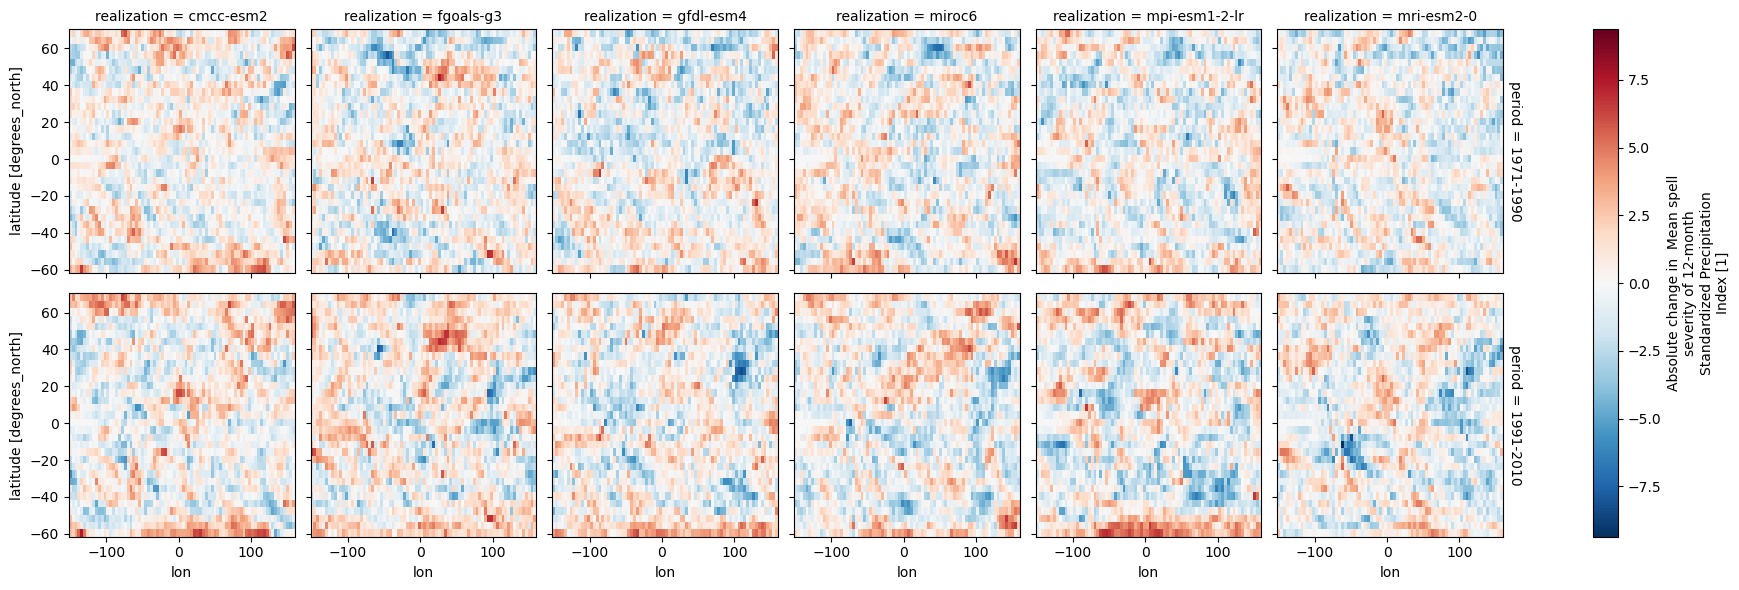

In [151]:
spi12sev_delta.plot(col='realization', row='period', )